# Phase 1 - Validation Suite: State U3 Unemployment Rate (LAUS)

**Scope:** validate the state headline (U3) unemployment-rate dataset (`{ABBR}UR`, monthly seasonally adjusted, percent, BLS Local Area Unemployment Statistics via FRED/ALFRED) before any modeling. State labor force (`{ABBR}LF`) is pulled for the labor-force-weighted reconciliation; national UNRATE for the benchmark.

**Downstream uses and what they stress:**

| Use case | Failure modes probed here |
|---|---|
| Forecasting | persistence/stationarity of a bounded rate, residual seasonality, outliers (V5, V7) |
| Lead-lag | timestamp & alignment conventions, sign orientation vs payrolls (V3, V8) |
| Backtesting | point-in-time integrity, benchmark revisions, publication lag, look-ahead guards (V3, V4, V9) |

**Where U3 sits among the three state datasets.** This suite is the sibling of the state continued-claims and nonfarm-payroll suites; U3 is a *third distinct profile* and the checks are tuned to it:

| | Continued claims | Nonfarm payrolls | **U3 unemployment** |
|---|---|---|---|
| Data type | level (weekly count) | level (monthly count, thousands) | **rate (percent, bounded)** |
| Frequency | weekly | monthly | **monthly** (ref. week incl. the 12th) |
| Seasonal adjustment | NSA | SA | **SA** (seasonality should be absent) |
| Revised after first print? | ~0% | ~99% | **moderate** (~74%, but quantized to 0.1pp; annual benchmark) |
| Level behaviour | cyclical | trending (I(1)) | **cyclical, bounded, no trend** |
| Reconciliation with national | sum (PR/VI gap) | sum (~exact) | **labor-force-weighted mean** (rates cannot be summed) |
| Publication lag | ~10 days | ~50 days | **~50 days** (same joint State Employment & Unemployment report as NFP) |

The two headline consequences for U3: (1) it is a **bounded rate**, so features are *changes in percentage points*, not growth rates, and long-run mean-reversion (not a trend) governs stationarity; (2) reconciliation requires **weighting by labor force** - the naive average of state rates is biased. Each check states its question and pass criterion up front; the last cells render the report and go/no-go gates.

In [1]:
import os, time, json, hashlib
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

DATA_FILES = {
    "vintage": "ur_vintage_first_release.csv",
    "current": "ur_current_history.csv",
    "pit":     "ur_pit_features.csv",
}

checks = []

def add_check(module, check_id, name, result, metric="", threshold="", note=""):
    assert result in ("PASS", "WARN", "FAIL")
    checks.append(dict(module=module, id=check_id, check=name, result=result,
                       metric=str(metric), threshold=str(threshold), note=note))
    print(f"[{result:4s}] {check_id:6s} {name}  |  {metric}  (criterion: {threshold})")
    if note:
        print(f"       note: {note}")


def fred_get(params, retries=5):
    params = {**params, "api_key": FRED_API_KEY, "file_type": "json"}
    for attempt in range(retries):
        data = requests.get(FRED_URL, params=params, timeout=180).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1)); continue
            raise ValueError(data["error_message"])
        return data
    raise RuntimeError(f"Rate limit persists: {params.get('series_id')}")


def fred_obs(params, retries=5):
    return [o for o in fred_get(params, retries).get("observations", []) if o["value"] != "."]

print("Setup ok.")

Setup ok.


## Maintained hypotheses - LAUS publication mechanics

**H1 - Publication schedule.** The state U3 unemployment rate is published in the BLS *State Employment and Unemployment* report - the **same monthly release as state nonfarm payrolls**, roughly **three weeks after** the national Employment Situation, about **7 weeks (~50 days) after the reference month**, on a Friday.
→ tested by **V3.2** (national release weekday), **V3.3** (state publication lag ≈ 50 days), **V3.4** (follows the national jobs report).

**H2 - Reference period.** The rate reflects labor-force status in the **week containing the 12th** of the reference month; FRED stamps the observation on the **1st of that month**.
→ tested by **V2.1** (all observation dates are month-starts).

**H3 - Revision structure.** LAUS estimates are re-estimated and **benchmarked annually** (re-anchored to CES/QCEW inputs and re-seasonally-adjusted each winter). Revisions are moderate and **quantized to 0.1 percentage points** because the rate is published to one decimal - so many true revisions round to zero.
→ quantified by **V4** (first-vs-current revision, benchmark clustering) and **V9** (feature contamination).

**Vocabulary.** *First release* = the initial estimate for a month (its `first_release_date`). *Current* = the latest value after all revisions and benchmarks. *Two clocks* = observation time (the month measured, V2) vs information time (when it became known, V3). Because the rate is bounded, feature transforms are **changes in percentage points** (`ur_t0 - ur_t12`), not percent changes.

## V0 - Build the dataset from the FRED/ALFRED API (self-contained)

**V0a** auto-loads on-disk CSVs when vintage + current exist (pit too if present); otherwise it fetches the UR ALFRED first-release table (`output_type=4`), UR current history and LF labor-force history (~155 calls, ~3-4 min). Set `FORCE_REFRESH = True` in V0a to ignore cache. **V0b** assembles the monthly point-in-time panel if pit is missing, persists three CSVs and pulls national UNRATE.

In [2]:
# ── V0a. Fetch state U3 unemployment + labor force from the FRED/ALFRED API ────
FORCE_REFRESH = False   # True -> ignore on-disk CSVs and re-fetch from the API

V0A_CACHE_KEYS = ("vintage", "current")   # V0a only needs these; pit is built in V0b


def _cache_file_info(path):
    """Return size/mtime for an on-disk CSV, or None if missing."""
    if not os.path.exists(path):
        return None
    st = os.stat(path)
    return {"path": path, "size_mb": st.st_size / 1e6,
            "mtime": pd.Timestamp(st.st_mtime, unit="s")}


_cache_status = {k: _cache_file_info(DATA_FILES[k]) for k in DATA_FILES}
_v0a_cache_ok = all(_cache_status[k] for k in V0A_CACHE_KEYS)
_full_cache_ok = all(_cache_status.values())

print("V0a — cache probe:")
for key, info in _cache_status.items():
    path = DATA_FILES[key]
    if info is None:
        print(f"  {key:8s}  missing  ({path})")
    else:
        print(f"  {key:8s}  ok  {info['size_mb']:6.1f} MB  mtime {info['mtime'].date()}  ({path})")

if _full_cache_ok:
    print("  → will load vintage, current, and pit from cache.")
elif _v0a_cache_ok:
    print("  → will load vintage and current from cache; pit will be rebuilt in V0b.")
else:
    print("  → no cache — will fetch from FRED/ALFRED (~155 calls, ~3-4 min).")

STATES = [
    ("Alabama","AL","01"),("Alaska","AK","02"),("Arizona","AZ","04"),("Arkansas","AR","05"),
    ("California","CA","06"),("Colorado","CO","08"),("Connecticut","CT","09"),("Delaware","DE","10"),
    ("District of Columbia","DC","11"),("Florida","FL","12"),("Georgia","GA","13"),("Hawaii","HI","15"),
    ("Idaho","ID","16"),("Illinois","IL","17"),("Indiana","IN","18"),("Iowa","IA","19"),
    ("Kansas","KS","20"),("Kentucky","KY","21"),("Louisiana","LA","22"),("Maine","ME","23"),
    ("Maryland","MD","24"),("Massachusetts","MA","25"),("Michigan","MI","26"),("Minnesota","MN","27"),
    ("Mississippi","MS","28"),("Missouri","MO","29"),("Montana","MT","30"),("Nebraska","NE","31"),
    ("Nevada","NV","32"),("New Hampshire","NH","33"),("New Jersey","NJ","34"),("New Mexico","NM","35"),
    ("New York","NY","36"),("North Carolina","NC","37"),("North Dakota","ND","38"),("Ohio","OH","39"),
    ("Oklahoma","OK","40"),("Oregon","OR","41"),("Pennsylvania","PA","42"),("Rhode Island","RI","44"),
    ("South Carolina","SC","45"),("South Dakota","SD","46"),("Tennessee","TN","47"),("Texas","TX","48"),
    ("Utah","UT","49"),("Vermont","VT","50"),("Virginia","VA","51"),("Washington","WA","53"),
    ("West Virginia","WV","54"),("Wisconsin","WI","55"),("Wyoming","WY","56"),
]
# Series: {ABBR}UR = SA U3 rate (validated series); {ABBR}LF = SA labor force (weights for reconciliation)

def fetch_vintage(series_id):
    return fred_obs({"series_id": series_id, "realtime_start": "1776-07-04",
                     "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000})
def fetch_current(series_id):
    return fred_obs({"series_id": series_id, "observation_start": "1976-01-01", "limit": 100000})


if _v0a_cache_ok and not FORCE_REFRESH:
    df_v = pd.read_csv(DATA_FILES["vintage"], parse_dates=["obs_date", "first_release_date"])
    df_c = pd.read_csv(DATA_FILES["current"], parse_dates=["obs_date"])
    if _full_cache_ok:
        pit = pd.read_csv(DATA_FILES["pit"], parse_dates=["as_of_date", "ur_latest_obs"])
        print("Loaded cached CSVs (vintage, current, pit).")
    else:
        pit = None
        print("Loaded cached CSVs (vintage, current). pit will be rebuilt in V0b.")
else:
    if _v0a_cache_ok and FORCE_REFRESH:
        print("FORCE_REFRESH=True — ignoring on-disk cache, fetching from API.")
    vintage_rows, current_rows, failed = [], [], []
    for i, (name, abbr, fips) in enumerate(STATES):
        try:
            for o in fetch_vintage(f"{abbr}UR"):
                vintage_rows.append({"state": name, "abbr": abbr, "fips": fips,
                    "obs_date": pd.to_datetime(o["date"]),
                    "first_release_date": pd.to_datetime(o["realtime_start"]),
                    "superseded_date": o["realtime_end"], "value_first_release": float(o["value"])})
            time.sleep(0.3)
            for o in fetch_current(f"{abbr}UR"):
                current_rows.append({"state": name, "abbr": abbr, "series": "ur",
                    "obs_date": pd.to_datetime(o["date"]), "value_current": float(o["value"])})
            time.sleep(0.3)
            for o in fetch_current(f"{abbr}LF"):
                current_rows.append({"state": name, "abbr": abbr, "series": "lf",
                    "obs_date": pd.to_datetime(o["date"]), "value_current": float(o["value"])})
            print(f"[{i+1:2d}/51] {abbr}UR / {abbr}LF ok")
        except Exception as e:
            print(f"[{i+1:2d}/51] {abbr} FAILED - {e}"); failed.append(abbr)
        time.sleep(0.3)
    if failed:
        raise RuntimeError(f"Fetch failed for {failed} - re-run this cell (rate limits are transient).")
    df_v = pd.DataFrame(vintage_rows)
    df_v["is_current"]   = df_v["superseded_date"] == "9999-12-31"
    df_v["pub_lag_days"] = (df_v["first_release_date"] - df_v["obs_date"]).dt.days
    df_v = df_v.drop(columns="superseded_date")
    df_c = pd.DataFrame(current_rows)
    pit = None

print(f"vintage rows: {len(df_v):,}   current rows: {len(df_c):,}")

[ 1/51] ALUR / ALLF ok
[ 2/51] AKUR / AKLF ok
[ 3/51] AZUR / AZLF ok
[ 4/51] ARUR / ARLF ok
[ 5/51] CAUR / CALF ok
[ 6/51] COUR / COLF ok
[ 7/51] CTUR / CTLF ok
[ 8/51] DEUR / DELF ok
[ 9/51] DCUR / DCLF ok
[10/51] FLUR / FLLF ok
[11/51] GAUR / GALF ok
[12/51] HIUR / HILF ok
[13/51] IDUR / IDLF ok
[14/51] ILUR / ILLF ok
[15/51] INUR / INLF ok
[16/51] IAUR / IALF ok
[17/51] KSUR / KSLF ok
[18/51] KYUR / KYLF ok
[19/51] LAUR / LALF ok
[20/51] MEUR / MELF ok
[21/51] MDUR / MDLF ok
[22/51] MAUR / MALF ok
[23/51] MIUR / MILF ok
[24/51] MNUR / MNLF ok
[25/51] MSUR / MSLF ok
[26/51] MOUR / MOLF ok
[27/51] MTUR / MTLF ok
[28/51] NEUR / NELF ok
[29/51] NVUR / NVLF ok
[30/51] NHUR / NHLF ok
[31/51] NJUR / NJLF ok
[32/51] NMUR / NMLF ok
[33/51] NYUR / NYLF ok
[34/51] NCUR / NCLF ok
[35/51] NDUR / NDLF ok
[36/51] OHUR / OHLF ok
[37/51] OKUR / OKLF ok
[38/51] ORUR / ORLF ok
[39/51] PAUR / PALF ok
[40/51] RIUR / RILF ok
[41/51] SCUR / SCLF ok
[42/51] SDUR / SDLF ok
[43/51] TNUR / TNLF ok
[44/51] TXU

In [3]:
# ── V0b. Assemble the monthly point-in-time panel, persist, fetch national ────
N_LAGS = 13

if pit is None:
    AS_OF_GRID = pd.date_range(df_v["first_release_date"].min().to_period("M").to_timestamp(),
                               df_v["first_release_date"].max().to_period("M").to_timestamp(), freq="MS")

    def build_pit(vint, n_lags, grid):
        """Last n_lags monthly first-release readings available at each as-of month (cummax frontier)."""
        out = {}
        for state, g in vint.groupby("state", sort=False):
            g = g.sort_values("obs_date")
            rel_eff = g["first_release_date"].cummax().values
            vals = g["value_first_release"].values
            obsd = g["obs_date"].values
            n_avail = np.searchsorted(rel_eff, grid.values, side="right")
            for j, as_of in enumerate(grid):
                k = n_avail[j]
                if k < n_lags:
                    continue
                row = {f"ur_t{m}": vals[k - 1 - m] for m in range(n_lags)}
                row["ur_latest_obs"] = pd.Timestamp(obsd[k - 1])
                row["ur_lag_months"] = (as_of.to_period("M") - pd.Timestamp(obsd[k - 1]).to_period("M")).n
                out[(as_of, state)] = row
        return out

    pit = pd.DataFrame([{"as_of_date": k[0], "state": k[1], **row}
                        for k, row in build_pit(df_v, N_LAGS, AS_OF_GRID).items()])
    # A RATE: features are CHANGES in percentage points, not percent changes
    pit["ur_mom1_chg"] = pit["ur_t0"] - pit["ur_t1"]
    pit["ur_mom3_chg"] = pit["ur_t0"] - pit["ur_t3"]
    pit["ur_yoy_chg"]  = pit["ur_t0"] - pit["ur_t12"]
    df_v.to_csv(DATA_FILES["vintage"], index=False)
    df_c.to_csv(DATA_FILES["current"], index=False)
    pit.to_csv(DATA_FILES["pit"], index=False)
    print("Dataset written to CSVs.")

ur_c = df_c[df_c["series"] == "ur"].copy()   # UR current history (validated series)
lf_c = df_c[df_c["series"] == "lf"].copy()   # labor force current history (reconciliation weights)
print(f"pit rows: {len(pit):,}   UR current: {len(ur_c):,}   LF current: {len(lf_c):,}")

# National UNRATE: current + first-release table + vintage dates
nat_cur = pd.DataFrame(fred_obs({"series_id": "UNRATE", "observation_start": "1976-01-01", "limit": 100000}))
nat_cur["obs_date"] = pd.to_datetime(nat_cur["date"]); nat_cur["value"] = nat_cur["value"].astype(float)
nat_v = pd.DataFrame(fred_obs({"series_id": "UNRATE", "realtime_start": "1776-07-04",
                               "realtime_end": "9999-12-31", "output_type": 4, "limit": 100000}))
nat_v["obs_date"] = pd.to_datetime(nat_v["date"]); nat_v["first_release_date"] = pd.to_datetime(nat_v["realtime_start"])
nat_v["value"] = nat_v["value"].astype(float)
nat_v["pub_lag_days"] = (nat_v["first_release_date"] - nat_v["obs_date"]).dt.days
nat_vdates = pd.to_datetime(pd.Series(requests.get(
    "https://api.stlouisfed.org/fred/series/vintagedates",
    params={"series_id": "UNRATE", "api_key": FRED_API_KEY, "file_type": "json", "limit": 10000},
    timeout=60).json()["vintage_dates"]))
print(f"national UNRATE: {len(nat_cur)} current obs, {len(nat_v)} first releases, {len(nat_vdates)} vintage dates")

Dataset written to CSVs.
pit rows: 11,133   UR current: 30,804   LF current: 30,804
national UNRATE: 605 current obs, 795 first releases, 797 vintage dates


## V1 — Structural integrity

| Check | Question it answers |
|---|---|
| V1.1 | Do we actually have all 51 states in every table? |
| V1.2 | Is (state, month) a unique key — no double-loaded rows? |
| V1.3 | Are the key fields complete (no nulls)? |
| V1.4 | Is every rate finite and in a plausible bounded range (0–40%)? |
| V1.4b | Are the rates quantized to 0.1 percentage points, as published? |
| V1.5 | Did any state's fetch silently truncate? |

The validated series is the seasonally-adjusted U3 rate (`{ABBR}UR`). Labor force (`{ABBR}LF`) is auxiliary (used later for reconciliation). Datasets: **vintage** = first-release (`df_v`), **current** = revised (`ur_c`), **pit** = point-in-time panel.

## V1.0 — Print datasets

In [37]:
df_v.head()

,state,abbr,fips,obs_date,first_release_date,value_first_release,is_current,pub_lag_days,rel_year
0,Alabama,AL,01,2007-06-01,2007-07-20,3.5,False,49,2007
1,Alabama,AL,01,2007-07-01,2007-08-17,3.7,False,47,2007
2,Alabama,AL,01,2007-08-01,2007-09-25,3.8,False,55,2007
3,Alabama,AL,01,2007-09-01,2007-10-19,3.7,False,48,2007
4,Alabama,AL,01,2007-10-01,2007-11-20,3.1,False,50,2007


In [38]:
df_v[['obs_date', 'first_release_date', 'value_first_release', 'pub_lag_days']].describe()

,obs_date,first_release_date,value_first_release,pub_lag_days
count,11745,11745,11745.000000,11745.000000
mean,2016-09-07 08:17:54.022988544,2016-10-29 15:05:55.862068992,5.447254,52.283355
min,2005-06-01 00:00:00,2005-07-22 00:00:00,1.600000,45.000000
25%,2011-12-01 00:00:00,2012-01-24 00:00:00,3.700000,48.000000
50%,2016-09-01 00:00:00,2016-10-21 00:00:00,4.800000,50.000000
75%,2021-07-01 00:00:00,2021-08-20 00:00:00,6.800000,53.000000
max,2026-05-01 00:00:00,2026-06-23 00:00:00,28.200000,111.000000
std,NaN,NaN,2.394136,8.513298


In [39]:
ur_c.head()

,state,abbr,series,obs_date,value_current
0,Alabama,AL,ur,1976-01-01,6.7
1,Alabama,AL,ur,1976-02-01,6.6
2,Alabama,AL,ur,1976-03-01,6.6
3,Alabama,AL,ur,1976-04-01,6.5
4,Alabama,AL,ur,1976-05-01,6.4


In [40]:
ur_c[['obs_date', 'value_current']].describe()

,obs_date,value_current
count,30804,30804.000000
mean,2001-02-14 22:38:56.423841152,5.702500
min,1976-01-01 00:00:00,1.700000
25%,1988-07-24 06:00:00,4.100000
50%,2001-02-15 00:00:00,5.300000
75%,2013-09-08 12:00:00,6.900000
max,2026-05-01 00:00:00,30.500000
std,NaN,2.178825


In [41]:
pit.head()

,as_of_date,state,ur_t0,ur_t1,ur_t2,ur_t3,ur_t4,ur_t5,ur_t6,ur_t7,ur_t8,ur_t9,ur_t10,ur_t11,ur_t12,ur_latest_obs,ur_lag_months,ur_mom1_chg,ur_mom3_chg,ur_yoy_chg
0,2008-08-01,Alabama,4.7,4.7,4.0,4.1,3.7,4.0,4.0,3.5,3.1,3.7,3.8,3.7,3.5,2008-06-01,2,0.0,0.6,1.2
1,2008-09-01,Alabama,5.1,4.7,4.7,4.0,4.1,3.7,4.0,4.0,3.5,3.1,3.7,3.8,3.7,2008-07-01,2,0.4,1.1,1.4
2,2008-10-01,Alabama,4.9,5.1,4.7,4.7,4.0,4.1,3.7,4.0,4.0,3.5,3.1,3.7,3.8,2008-08-01,2,-0.2,0.2,1.1
3,2008-11-01,Alabama,5.3,4.9,5.1,4.7,4.7,4.0,4.1,3.7,4.0,4.0,3.5,3.1,3.7,2008-09-01,2,0.4,0.6,1.6
4,2008-12-01,Alabama,5.6,5.3,4.9,5.1,4.7,4.7,4.0,4.1,3.7,4.0,4.0,3.5,3.1,2008-10-01,2,0.3,0.5,2.5


In [42]:
pit[['as_of_date', 'ur_latest_obs', 'ur_t0']].describe()

,as_of_date,ur_latest_obs,ur_t0
count,11133,11133,11133.000000
mean,2017-05-07 16:22:07.081649408,2017-03-03 22:56:06.208569344,5.495033
min,2006-08-01 00:00:00,2006-06-01 00:00:00,1.600000
25%,2012-11-01 00:00:00,2012-09-01 00:00:00,3.700000
50%,2017-05-01 00:00:00,2017-03-01 00:00:00,4.800000
75%,2021-12-01 00:00:00,2021-10-01 00:00:00,6.900000
max,2026-06-01 00:00:00,2026-04-01 00:00:00,28.200000
std,NaN,NaN,2.435505


## V1.1 — Count and plot number of states per dataset

V1.1 — unique states per table (criterion: 51 everywhere):
  vintage   51  [OK]
  current   51  [OK]
  pit       51  [OK]


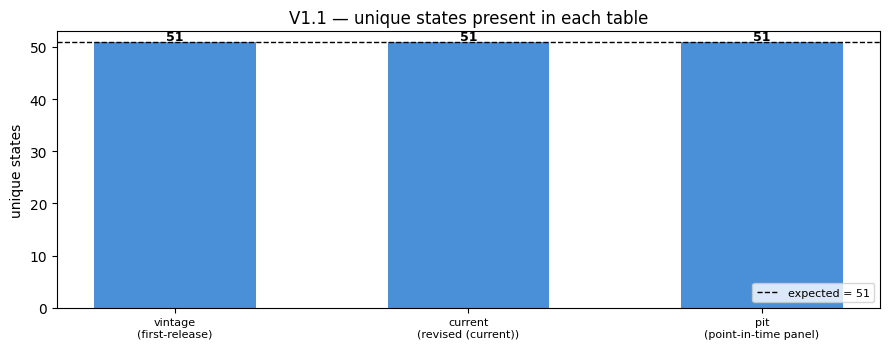

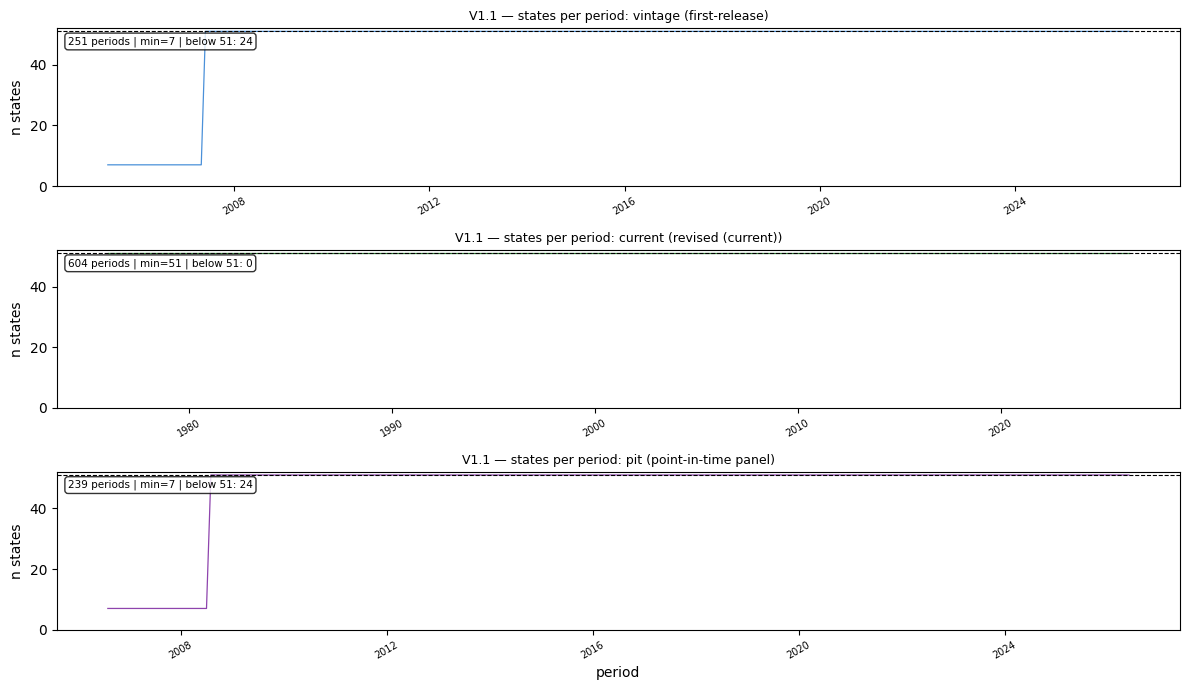

V1.1 — states per period summary (min / max / avg):
  vintage   min= 7  max=51  avg= 46.8  below 51: 24  (first-release)
  current   min=51  max=51  avg= 51.0  below 51: 0  (revised (current))
  pit       min= 7  max=51  avg= 46.6  below 51: 24  (point-in-time panel)

V1.1 — periods with < 51 states (all dates):

  vintage (first-release): 24 period(s)
    2005-06-01 00:00:00  (7 states)
    2005-07-01 00:00:00  (7 states)
    2005-08-01 00:00:00  (7 states)
    2005-09-01 00:00:00  (7 states)
    2005-10-01 00:00:00  (7 states)
    2005-11-01 00:00:00  (7 states)
    2005-12-01 00:00:00  (7 states)
    2006-01-01 00:00:00  (7 states)
    2006-02-01 00:00:00  (7 states)
    2006-03-01 00:00:00  (7 states)
    2006-04-01 00:00:00  (7 states)
    2006-05-01 00:00:00  (7 states)
    2006-06-01 00:00:00  (7 states)
    2006-07-01 00:00:00  (7 states)
    2006-08-01 00:00:00  (7 states)
    2006-09-01 00:00:00  (7 states)
    2006-10-01 00:00:00  (7 states)
    2006-11-01 00:00:00  (7 state

In [9]:
# V1.1 — count unique states per dataset, then plot states reporting each period
N_EXPECTED = 51

_DATASETS = [
    ("vintage", df_v, "obs_date",  "#4a90d9", "first-release"),
    ("current", ur_c, "obs_date",  "#2e7d32", "revised (current)"),
    ("pit",     pit,  "as_of_date", "#8e44ad", "point-in-time panel"),
]

n_states_tbl = {name: df["state"].nunique() for name, df, _, _, _ in _DATASETS}
print("V1.1 — unique states per table (criterion: 51 everywhere):")
for name, n in n_states_tbl.items():
    print(f"  {name:8s}  {n:2d}  [{'OK' if n == N_EXPECTED else 'MISSING'}]")

_labels = [f"{n}\n({tag})" for n, _, _, _, tag in _DATASETS]
_counts = [n_states_tbl[n] for n, _, _, _, _ in _DATASETS]
_colors = ["#4a90d9" if n == N_EXPECTED else "#d94a4a" for n in _counts]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=_colors, width=0.55)
ax.axhline(N_EXPECTED, color="black", ls="--", lw=1, label=f"expected = {N_EXPECTED}")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("unique states"); ax.set_ylim(0, N_EXPECTED + 2)
ax.set_title("V1.1 — unique states present in each table")
for bar, n in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 0.3, str(n), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

# states reporting per period over time (panel completeness by period)
per_period_stats = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (name, df, date_col, color, tag) in zip(axes, _DATASETS):
    per = df.groupby(date_col)["state"].nunique().sort_index()
    per_period_stats[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(N_EXPECTED, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n states"); ax.set_ylim(0, N_EXPECTED + 1)
    ax.set_title(f"V1.1 — states per period: {name} ({tag})", fontsize=9)
    below = int((per < N_EXPECTED).sum())
    ax.text(0.01, 0.95, f"{len(per):,} periods | min={per.min()} | below {N_EXPECTED}: {below}",
            transform=ax.transAxes, va="top", fontsize=7.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print("V1.1 — states per period summary (min / max / avg):")
for name, _, _, _, tag in _DATASETS:
    per = per_period_stats[name]
    print(f"  {name:8s}  min={per.min():2d}  max={per.max():2d}  avg={per.mean():5.1f}  "
          f"below {N_EXPECTED}: {int((per < N_EXPECTED).sum())}  ({tag})")

print(f"\nV1.1 — periods with < {N_EXPECTED} states (all dates):")
for name, _, _, _, tag in _DATASETS:
    incomplete = per_period_stats[name][per_period_stats[name] < N_EXPECTED]
    print(f"\n  {name} ({tag}): {len(incomplete):,} period(s)")
    if incomplete.empty:
        print("    (none)")
    else:
        for dt, n in incomplete.items():
            print(f"    {dt}  ({int(n)} states)")

## V1.2 — Count and plot (state, month) keys per dataset

V1.2 — (state, month) key integrity (criterion: 0 duplicate rows):
  vintage   rows=11,745  unique keys=11,745  dup rows=0  [OK]  key=(state, obs_date) (first-release)
  current   rows=30,804  unique keys=30,804  dup rows=0  [OK]  key=(state, obs_date) (revised (current))
  pit       rows=11,133  unique keys=11,133  dup rows=0  [OK]  key=(as_of_date, state) (point-in-time panel)


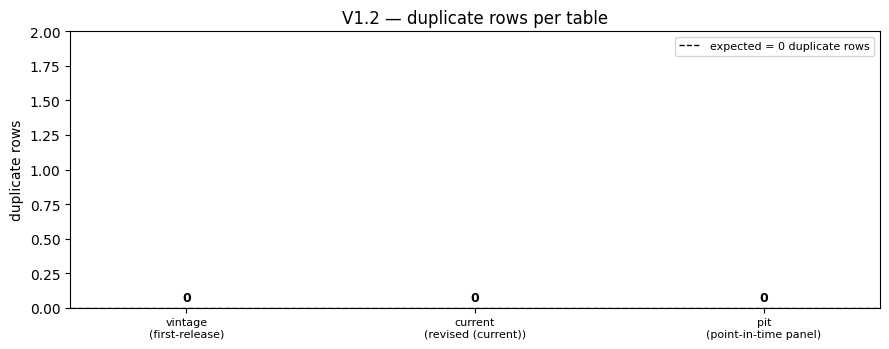

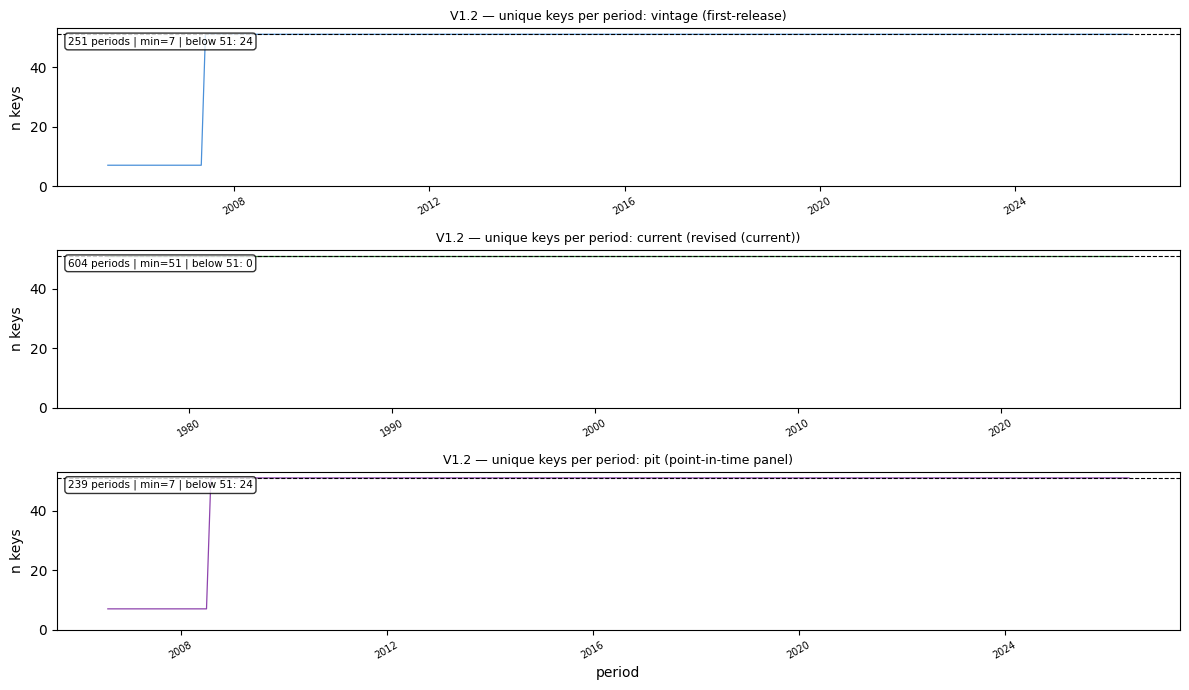


V1.2 — duplicate key instances (all):
  vintage (first-release): 0 duplicate row(s)  (none)
  current (revised (current)): 0 duplicate row(s)  (none)
  pit (point-in-time panel): 0 duplicate row(s)  (none)


In [10]:
# V1.2 — count and plot (state, month) keys per dataset (single validated series: UR)
_DATASETS_V12 = [
    ("vintage", df_v, "obs_date",  ["state", "obs_date"],     51, "#4a90d9", "first-release"),
    ("current", ur_c, "obs_date",  ["state", "obs_date"],     51, "#2e7d32", "revised (current)"),
    ("pit",     pit,  "as_of_date", ["as_of_date", "state"],  51, "#8e44ad", "point-in-time panel"),
]

_key_stats = {}
for name, df, _, key_cols, _, _, _ in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    _key_stats[name] = {"rows": len(df), "unique": df.drop_duplicates(key_cols).shape[0], "dup_rows": int(dup_mask.sum())}

print("V1.2 — (state, month) key integrity (criterion: 0 duplicate rows):")
for name, _, _, key_cols, expected, _, tag in _DATASETS_V12:
    s = _key_stats[name]
    key_label = "(as_of_date, state)" if "as_of_date" in key_cols else "(state, obs_date)"
    print(f"  {name:8s}  rows={s['rows']:,}  unique keys={s['unique']:,}  dup rows={s['dup_rows']}  "
          f"[{'OK' if s['dup_rows'] == 0 else 'DUP'}]  key={key_label} ({tag})")

_labels = [f"{n}\n({tag})" for n, _, _, _, _, _, tag in _DATASETS_V12]
_dup_counts = [_key_stats[n]["dup_rows"] for n, _, _, _, _, _, _ in _DATASETS_V12]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _dup_counts, color=["#2e7d32" if d == 0 else "#d94a4a" for d in _dup_counts], width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 duplicate rows")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("duplicate rows"); ax.set_ylim(0, max(_dup_counts + [1]) + 1)
ax.set_title("V1.2 — duplicate rows per table")
for bar, d in zip(bars, _dup_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, d + 0.05, str(d), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

# unique keys per period over time
per_keys = {}
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, (name, df, date_col, key_cols, expected, color, tag) in zip(axes, _DATASETS_V12):
    per = df.drop_duplicates(key_cols).groupby(date_col).size().sort_index()
    per_keys[name] = per
    ax.plot(per.index, per.values, color=color, lw=0.9)
    ax.axhline(expected, color="black", ls="--", lw=0.8)
    ax.set_ylabel("n keys"); ax.set_ylim(0, expected + 2)
    ax.set_title(f"V1.2 — unique keys per period: {name} ({tag})", fontsize=9)
    ax.text(0.01, 0.95, f"{len(per):,} periods | min={per.min()} | below {expected}: {int((per < expected).sum())}",
            transform=ax.transAxes, va="top", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print("\nV1.2 — duplicate key instances (all):")
for name, df, _, key_cols, _, _, tag in _DATASETS_V12:
    dup_mask = df.duplicated(key_cols, keep=False)
    print(f"  {name} ({tag}): {int(dup_mask.sum())} duplicate row(s)" + ("" if dup_mask.any() else "  (none)"))
    if dup_mask.any():
        print(df.loc[dup_mask, key_cols].value_counts().rename("n_rows").reset_index().to_string(index=False))

## V1.3 — Count and plot nulls in the key fields

V1.3 — nulls in key fields (criterion: 0 nulls anywhere):

  vintage (first-release): 0 null(s)  [OK]
    state                   0
    obs_date                0
    first_release_date      0
    value_first_release     0

  current (revised (current)): 0 null(s)  [OK]
    state                   0
    obs_date                0
    value_current           0

  pit (point-in-time panel): 0 null(s)  [OK]
    as_of_date              0
    state                   0


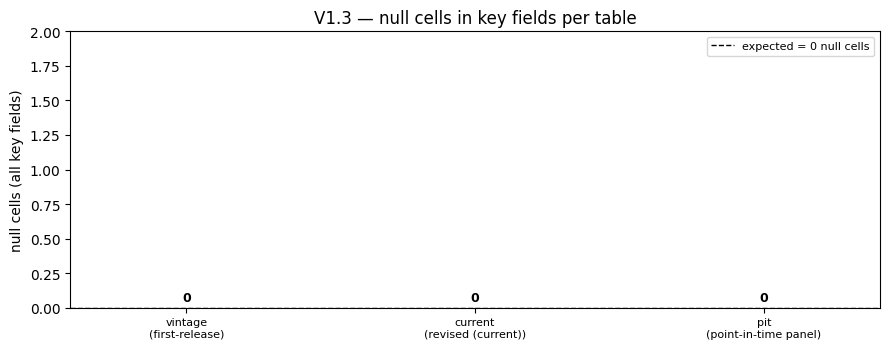

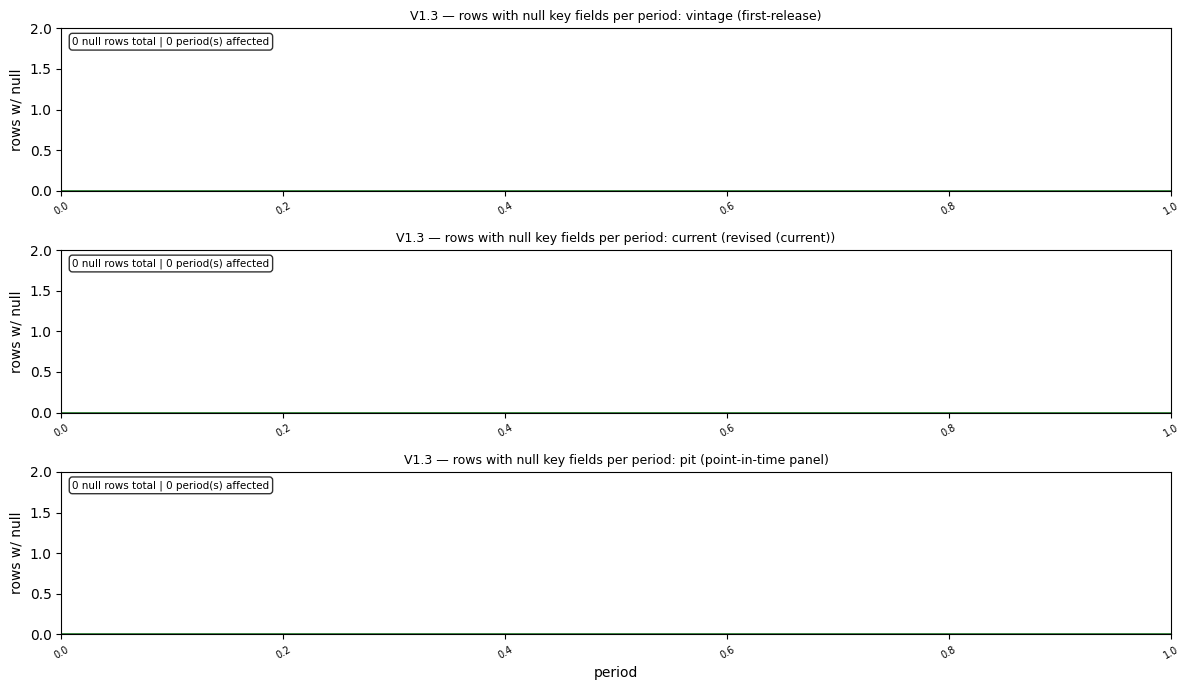


V1.3 — rows with null key fields (all):
  vintage (first-release): 0 row(s)  (none)
  current (revised (current)): 0 row(s)  (none)
  pit (point-in-time panel): 0 row(s)  (none)


In [11]:
# V1.3 — count and plot nulls in key fields per dataset
_KEY_FIELDS = {
    "vintage": ["state", "obs_date", "first_release_date", "value_first_release"],
    "current": ["state", "obs_date", "value_current"],
    "pit":     ["as_of_date", "state"],
}
_DATE_COL = {"vintage": "obs_date", "current": "obs_date", "pit": "as_of_date"}
_COLORS = {"vintage": "#4a90d9", "current": "#2e7d32", "pit": "#8e44ad"}
_TAGS = {"vintage": "first-release", "current": "revised (current)", "pit": "point-in-time panel"}
_DFS = {"vintage": df_v, "current": ur_c, "pit": pit}

_null_by_field = {n: _DFS[n][f].isna().sum() for n, f in _KEY_FIELDS.items()}
_null_rows = {n: int(_DFS[n][f].isna().any(axis=1).sum()) for n, f in _KEY_FIELDS.items()}

print("V1.3 — nulls in key fields (criterion: 0 nulls anywhere):")
for name, fields in _KEY_FIELDS.items():
    tot = int(_DFS[name][fields].isna().sum().sum())
    print(f"\n  {name} ({_TAGS[name]}): {tot} null(s)  [{'OK' if tot == 0 else 'NULL'}]")
    for field, n in _null_by_field[name].items():
        print(f"    {field:22s}  {int(n):,}")

_labels = [f"{n}\n({_TAGS[n]})" for n in _KEY_FIELDS]
_totals = [int(_null_by_field[n].sum()) for n in _KEY_FIELDS]
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(_labels)), _totals, color=["#2e7d32" if t == 0 else "#d94a4a" for t in _totals], width=0.55)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0 null cells")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("null cells (all key fields)"); ax.set_ylim(0, max(_totals + [1]) + 1)
ax.set_title("V1.3 — null cells in key fields per table")
for bar, t in zip(bars, _totals):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.05, str(t), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

# rows with any null key field per period over time
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
for ax, name in zip(axes, _KEY_FIELDS):
    df = _DFS[name]; fields = _KEY_FIELDS[name]
    per = df.loc[df[fields].isna().any(axis=1)].groupby(_DATE_COL[name]).size().sort_index()
    ax.plot(per.index, per.values, color=_COLORS[name], lw=0.9) if len(per) else ax.axhline(0, color="#2e7d32", lw=2)
    ax.set_ylabel("rows w/ null"); ax.set_ylim(0, max(per.max() if len(per) else 0, 1) + 1)
    ax.set_title(f"V1.3 — rows with null key fields per period: {name} ({_TAGS[name]})", fontsize=9)
    ax.text(0.01, 0.95, f"{_null_rows[name]:,} null rows total | {len(per):,} period(s) affected",
            transform=ax.transAxes, va="top", fontsize=7.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[-1].set_xlabel("period"); plt.tight_layout(); plt.show()

print("\nV1.3 — rows with null key fields (all):")
for name in _KEY_FIELDS:
    bad = _DFS[name][_DFS[name][_KEY_FIELDS[name]].isna().any(axis=1)]
    print(f"  {name} ({_TAGS[name]}): {len(bad):,} row(s)" + ("" if len(bad) else "  (none)"))

## V1.4 — Values finite and in a plausible bounded range

V1.4 — rate finite and in [0, 40]% (criterion: 0 bad rows):
  vintage   bad rows=0  [OK]  observed [1.6, 28.2]%  (first-release)
  current   bad rows=0  [OK]  observed [1.7, 30.5]%  (revised (current))


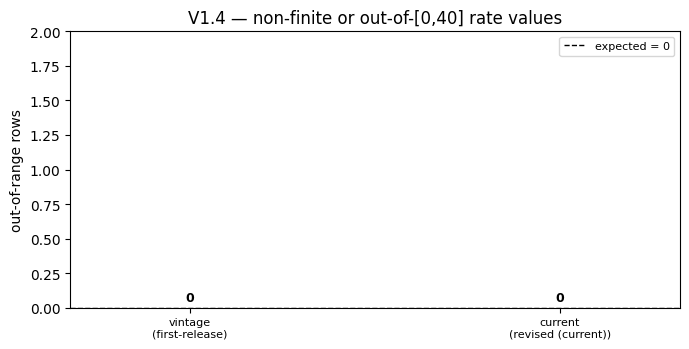

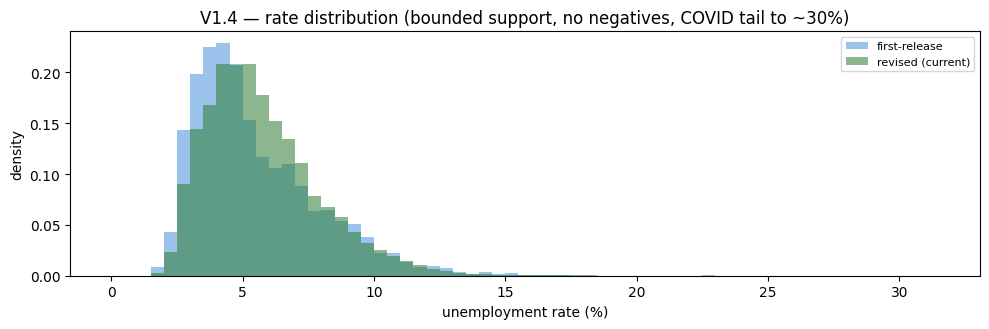

In [12]:
# V1.4 — the rate is bounded: every value finite and in [0, 40] percent
_VAL_COLS = {
    "vintage": ("value_first_release", df_v, "#4a90d9", "first-release"),
    "current": ("value_current",       ur_c, "#2e7d32", "revised (current)"),
}
LO, HI = 0.0, 40.0

def _bad_mask(series):
    return ~series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and np.isfinite(x) and LO <= x <= HI)

_bad = {}
for name, (col, df, color, tag) in _VAL_COLS.items():
    _bad[name] = df.loc[_bad_mask(df[col]), ["state", "obs_date", col]].rename(columns={col: "value"})

print(f"V1.4 — rate finite and in [{LO:.0f}, {HI:.0f}]% (criterion: 0 bad rows):")
for name, (col, df, _, tag) in _VAL_COLS.items():
    print(f"  {name:8s}  bad rows={len(_bad[name]):,}  [{'OK' if len(_bad[name]) == 0 else 'BAD'}]  "
          f"observed [{df[col].min():.1f}, {df[col].max():.1f}]%  ({tag})")

_labels = [f"{n}\n({t})" for n, (_, _, _, t) in _VAL_COLS.items()]
_counts = [len(_bad[n]) for n in _VAL_COLS]
fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.bar(range(len(_labels)), _counts, color=["#2e7d32" if c == 0 else "#d94a4a" for c in _counts], width=0.5)
ax.axhline(0, color="black", ls="--", lw=1, label="expected = 0")
ax.set_xticks(range(len(_labels))); ax.set_xticklabels(_labels, fontsize=8)
ax.set_ylabel("out-of-range rows"); ax.set_ylim(0, max(_counts + [1]) + 1)
ax.set_title("V1.4 — non-finite or out-of-[0,40] rate values")
for bar, c in zip(bars, _counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 0.05, str(c), ha="center", fontsize=9, fontweight="bold")
ax.legend(loc="upper right", fontsize=8); plt.tight_layout(); plt.show()

# distribution of the rate (first-release vs revised) — shows the bounded support
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(df_v["value_first_release"], bins=np.arange(0, 32, 0.5), alpha=0.55, color="#4a90d9", label="first-release", density=True)
ax.hist(ur_c["value_current"], bins=np.arange(0, 32, 0.5), alpha=0.55, color="#2e7d32", label="revised (current)", density=True)
ax.set_xlabel("unemployment rate (%)"); ax.set_ylabel("density")
ax.set_title("V1.4 — rate distribution (bounded support, no negatives, COVID tail to ~30%)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## V1.4b — Rates quantized to 0.1 percentage points, as published

V1.4b — 0.1pp quantization (criterion: 100% of values are exact 0.1 multiples):
  vintage   1-decimal share=100.0000%  distinct decimals=11  (first-release)
  current   1-decimal share=100.0000%  distinct decimals=11  (revised (current))


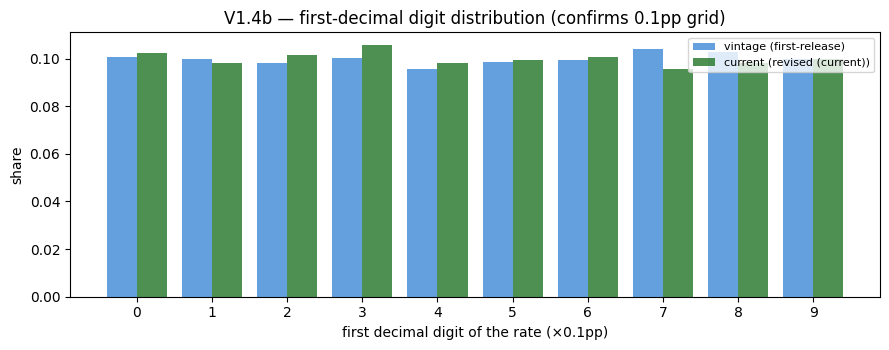


V1.4b — the 0.1pp granularity matters for V4: a sub-0.05pp revision rounds to zero,
so many true revisions are invisible in the published series (see V4.1).


In [13]:
# V1.4b — LAUS publishes the rate to one decimal; confirm the 0.1pp granularity
_DS = [("vintage", df_v, "value_first_release", "#4a90d9", "first-release"),
       ("current", ur_c, "value_current",       "#2e7d32", "revised (current)")]

print("V1.4b — 0.1pp quantization (criterion: 100% of values are exact 0.1 multiples):")
_share = {}
for name, df, col, color, tag in _DS:
    r10 = np.round(df[col] * 10)
    ok = np.isclose(r10, df[col] * 10)
    _share[name] = ok.mean()
    print(f"  {name:8s}  1-decimal share={ok.mean():.4%}  distinct decimals={df[col].round(1).sub(df[col].round(0)).round(1).nunique()}  ({tag})")

# distribution of the first decimal digit (0..9) — should be ~uniform, confirms 0.1 grid
fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.4
for i, (name, df, col, color, tag) in enumerate(_DS):
    digit = np.round((df[col] * 10) % 10).astype(int)
    vc = digit.value_counts().reindex(range(10), fill_value=0).sort_index()
    ax.bar(np.arange(10) + (i - 0.5) * w, (vc / vc.sum()).values, w, color=color, alpha=0.85, label=f"{name} ({tag})")
ax.set_xticks(range(10)); ax.set_xlabel("first decimal digit of the rate (×0.1pp)")
ax.set_ylabel("share"); ax.set_title("V1.4b — first-decimal digit distribution (confirms 0.1pp grid)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("\nV1.4b — the 0.1pp granularity matters for V4: a sub-0.05pp revision rounds to zero,")
print("so many true revisions are invisible in the published series (see V4.1).")

df_v missing cells — by obs_date: 1,056 of 12,801 (8.25%)
df_v missing cells — by first_release_date: 1,060 of 12,750 (8.31%)


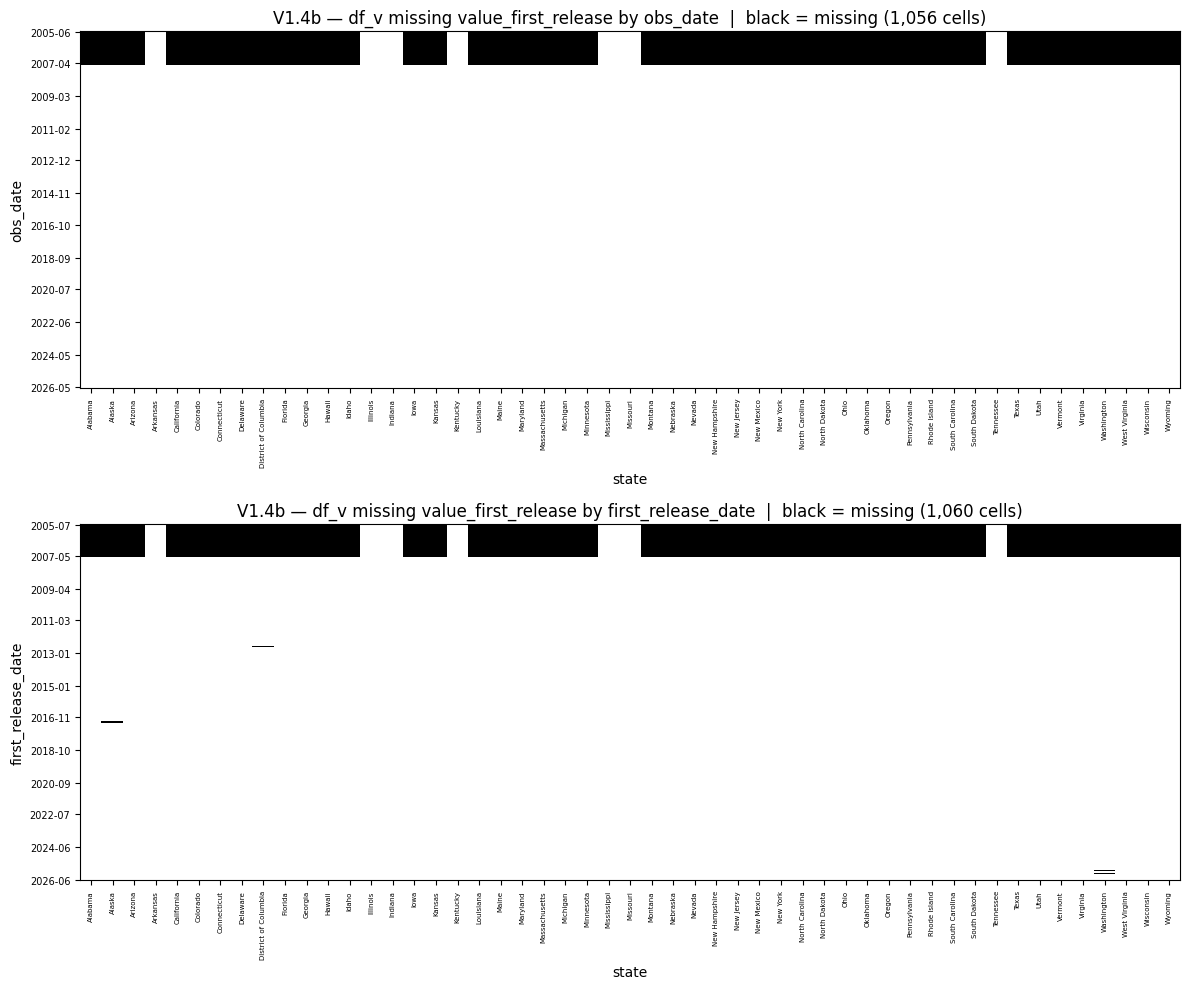

In [30]:
# V1.4b — df_v missing-value heatmaps (obs_date vs first_release_date grids)
_states_sorted = sorted(df_v["state"].unique())

_pivots = [
    ("obs_date", df_v.pivot_table(index="obs_date", columns="state", values="value_first_release")),
    ("first_release_date", df_v.pivot_table(index="first_release_date", columns="state", values="value_first_release")),
]

for label, wide in _pivots:
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    print(f"df_v missing cells — by {label}: {int(missing.values.sum()):,} of {missing.size:,} "
          f"({missing.values.mean():.2%})")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, (label, wide) in zip(axes, _pivots):
    wide = wide.reindex(columns=_states_sorted).sort_index()
    missing = wide.isna()
    cal = missing.index
    n_miss = int(missing.values.sum())
    ax.imshow(missing.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xticks(range(len(_states_sorted)))
    ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
    _yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
    ax.set_yticks(_yt)
    ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
    ax.set_xlabel("state")
    ax.set_ylabel(label)
    ax.set_title(f"V1.4b — df_v missing value_first_release by {label}  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


ur_c missing cells — by obs_date: 0 of 30,804 (0.00%)


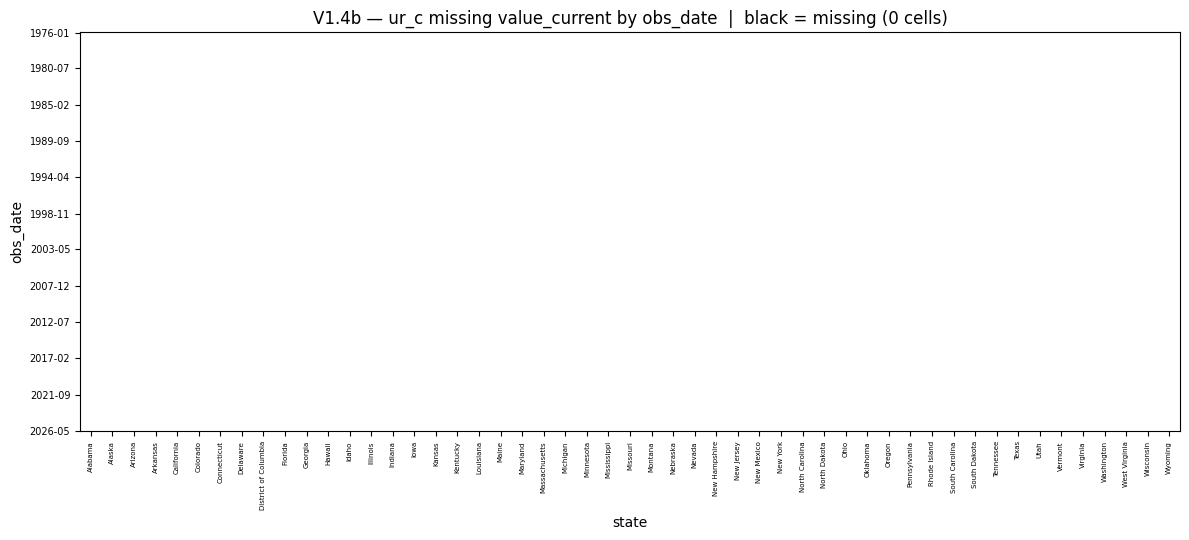

In [31]:
# V1.4b — ur_c missing-value heatmap (obs_date grid, revised current history)
_states_sorted = sorted(ur_c["state"].unique())

wide_c = ur_c.pivot_table(index="obs_date", columns="state", values="value_current")
wide_c = wide_c.reindex(columns=_states_sorted).sort_index()
missing_c = wide_c.isna()

print(f"ur_c missing cells — by obs_date: {int(missing_c.values.sum()):,} of {missing_c.size:,} "
      f"({missing_c.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_c.index
n_miss = int(missing_c.values.sum())
ax.imshow(missing_c.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("obs_date")
ax.set_title(f"V1.4b — ur_c missing value_current by obs_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


pit missing cells — ur_t0 by as_of_date: 1,056 of 12,189 (8.66%)


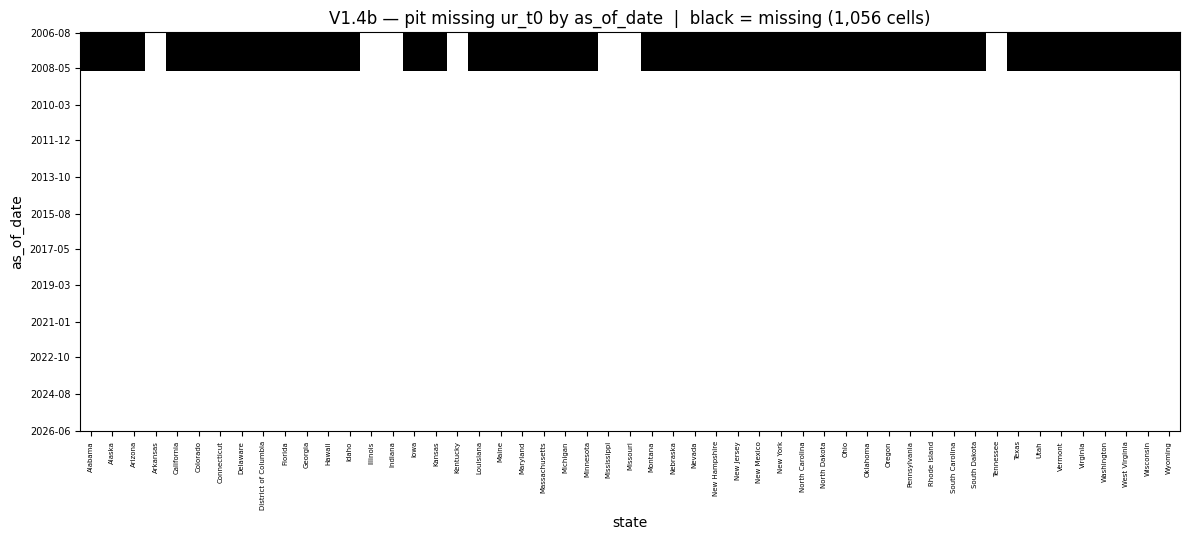

In [32]:
# V1.4b — pit missing-value heatmap (as_of_date grid, ur_t0)
_states_sorted = sorted(pit["state"].unique())

wide_pit = pit.pivot_table(index="as_of_date", columns="state", values="ur_t0")
wide_pit = wide_pit.reindex(columns=_states_sorted).sort_index()
missing_pit = wide_pit.isna()

print(f"pit missing cells — ur_t0 by as_of_date: {int(missing_pit.values.sum()):,} of {missing_pit.size:,} "
      f"({missing_pit.values.mean():.2%})")

fig, ax = plt.subplots(figsize=(12, 5.5))
cal = missing_pit.index
n_miss = int(missing_pit.values.sum())
ax.imshow(missing_pit.values, aspect="auto", cmap="Greys", interpolation="nearest", vmin=0, vmax=1)
ax.set_xticks(range(len(_states_sorted)))
ax.set_xticklabels(_states_sorted, rotation=90, fontsize=5)
_yt = np.linspace(0, len(cal) - 1, min(12, len(cal))).astype(int)
ax.set_yticks(_yt)
ax.set_yticklabels([cal[i].strftime("%Y-%m") for i in _yt], fontsize=7)
ax.set_xlabel("state")
ax.set_ylabel("as_of_date")
ax.set_title(f"V1.4b — pit missing ur_t0 by as_of_date  |  black = missing ({n_miss:,} cells)")
plt.tight_layout(); plt.show()


## V1.5 — Row counts per state (fetch truncation check)

V1.5 — row counts per state, U3 current history
  (criterion: max - min <= 3 months; spread=0)
  min=604  max=604  median=604  n_states=51

V1.5 — rows per state (sorted ascending):
               state  n_rows  vs_median
             Alabama     604        0.0
            Nebraska     604        0.0
              Nevada     604        0.0
       New Hampshire     604        0.0
          New Jersey     604        0.0
          New Mexico     604        0.0
            New York     604        0.0
      North Carolina     604        0.0
        North Dakota     604        0.0
                Ohio     604        0.0
            Oklahoma     604        0.0
             Montana     604        0.0
              Oregon     604        0.0
        Rhode Island     604        0.0
      South Carolina     604        0.0
        South Dakota     604        0.0
           Tennessee     604        0.0
               Texas     604        0.0
                Utah     604        0.0
             Vermo

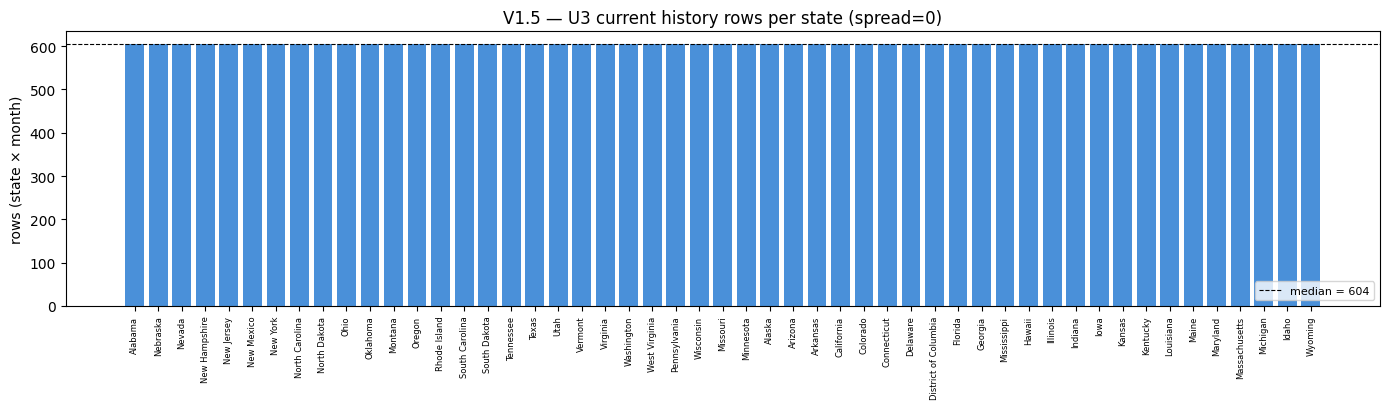

In [14]:
# V1.5 — row counts per state (fetch truncation check), revised (current) UR history
rc = ur_c.groupby("state").size().sort_values()
rc_min, rc_max, rc_median = int(rc.min()), int(rc.max()), float(rc.median())
spread = rc_max - rc_min

print("V1.5 — row counts per state, U3 current history")
print(f"  (criterion: max - min <= 3 months; spread={spread})")
print(f"  min={rc_min}  max={rc_max}  median={rc_median:.0f}  n_states={len(rc)}")
_rc_tbl = rc.reset_index(name="n_rows"); _rc_tbl["vs_median"] = _rc_tbl["n_rows"] - rc_median
print("\nV1.5 — rows per state (sorted ascending):")
print(_rc_tbl.to_string(index=False))
_out = _rc_tbl[_rc_tbl["vs_median"].abs() > 3]
print(f"\nV1.5 — states >3 months from median ({len(_out)}):")
print("  (none)" if _out.empty else _out.to_string(index=False))

_states = rc.index.tolist()
_cols = ["#d94a4a" if abs(v - rc_median) > 3 else "#4a90d9" for v in rc.values]
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.bar(range(len(_states)), rc.values, color=_cols, width=0.8)
ax.axhline(rc_median, color="black", ls="--", lw=0.8, label=f"median = {rc_median:.0f}")
ax.set_xticks(range(len(_states))); ax.set_xticklabels(_states, rotation=90, fontsize=6)
ax.set_ylabel("rows (state × month)")
ax.set_title(f"V1.5 — U3 current history rows per state (spread={spread})")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

## V2 — Calendar & frequency — *observation time: the month being measured*

The **observation clock**: `obs_date` stamps the reference month (FRED uses the 1st; the rate reflects the household-survey week containing the 12th). *What* the number measures — not when it was known (that is V3).

| Check | Question it answers |
|---|---|
| V2.1 | Do all observation dates follow the monthly (month-start) convention? |
| V2.2a | Are there missing months shared by all states (systematic BLS holes)? |
| V2.2b | Are there per-state (idiosyncratic) missing months? |
| V2.3 | Do all states cover the same window (balanced panel)? |

## V2.1 — Monthly month-start convention

V2.1 — obs_date is the 1st of the month (criterion: 100% day == 1):
  vintage  (first-release):  non-month-start rows=0  [OK]
  current  (revised (current)):  non-month-start rows=0  [OK]


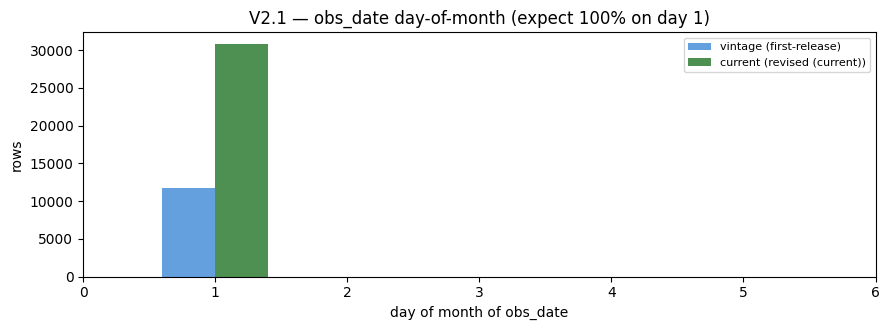

[PASS] V2.1   All obs_date are month-starts (monthly reference convention)  |  vintage=0, current=0 non-month-start  (criterion: == 0)


In [15]:
# V2.1 — every obs_date is a month-start (day == 1)
_DS = [("vintage", df_v, "#4a90d9", "first-release"), ("current", ur_c, "#2e7d32", "revised (current)")]
_bad = {}
for name, df, color, tag in _DS:
    _bad[name] = df.loc[df["obs_date"].dt.day != 1, ["state", "obs_date"]].drop_duplicates()

print("V2.1 — obs_date is the 1st of the month (criterion: 100% day == 1):")
for name, df, _, tag in _DS:
    print(f"  {name:8s} ({tag}):  non-month-start rows={len(_bad[name])}  [{'OK' if len(_bad[name]) == 0 else 'FAIL'}]")

# day-of-month distribution (should be entirely day 1)
fig, ax = plt.subplots(figsize=(9, 3.4))
w = 0.4
for i, (name, df, color, tag) in enumerate(_DS):
    dom = df["obs_date"].dt.day.value_counts().reindex(range(1, 32), fill_value=0).sort_index()
    ax.bar(np.arange(1, 32) + (i - 0.5) * w, dom.values, w, color=color, alpha=0.85, label=f"{name} ({tag})")
ax.set_xlim(0, 6); ax.set_xlabel("day of month of obs_date")
ax.set_ylabel("rows"); ax.set_title("V2.1 — obs_date day-of-month (expect 100% on day 1)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

add_check("V2", "V2.1", "All obs_date are month-starts (monthly reference convention)",
          "PASS" if all(len(_bad[n]) == 0 for n, *_ in _DS) else "FAIL",
          metric=f"vintage={len(_bad['vintage'])}, current={len(_bad['current'])} non-month-start",
          threshold="== 0")

## V2.2a — Missing months shared by all states (systematic BLS holes)

V2.2a — systematic (shared) missing months (criterion: documented BLS-wide holes):
  systematic months: 1
    2025-10-01  (51 states missing)


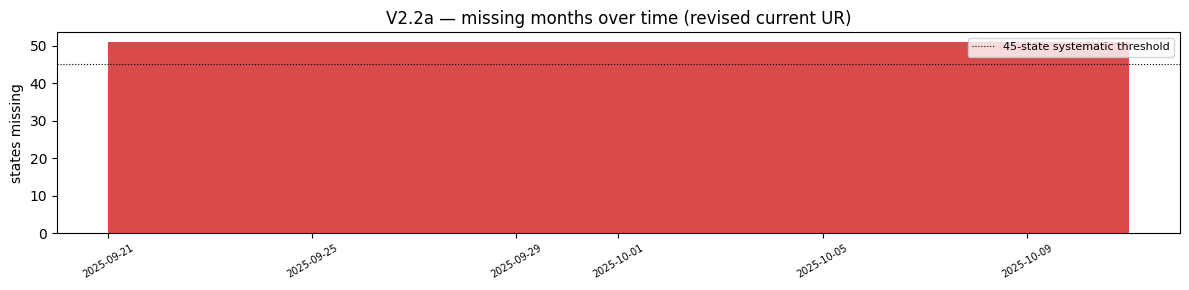

[WARN] V2.2a  Systematic (shared) missing months  |  1 month(s) missing across all states: 2025-10  (criterion: documented; shared BLS-wide holes tolerated as WARN)
       note: Oct-2025 is absent for every state AND national UNRATE — a BLS data-availability event (late-2025 federal shutdown). Do not interpolate across it.


In [16]:
# V2.2a — interior monthly gaps; a gap shared by (nearly) all states is a systematic BLS event
miss_by_month = {}
for state, g in ur_c.groupby("state"):
    cal = pd.date_range(g["obs_date"].min(), g["obs_date"].max(), freq="MS")
    for d in cal.difference(g["obs_date"]):
        miss_by_month[d] = miss_by_month.get(d, 0) + 1
systematic = {d: n for d, n in miss_by_month.items() if n >= 45}
idiosyncratic = {d: n for d, n in miss_by_month.items() if n < 45}

print("V2.2a — systematic (shared) missing months (criterion: documented BLS-wide holes):")
print(f"  systematic months: {len(systematic)}")
for d in sorted(systematic):
    print(f"    {d.date()}  ({systematic[d]} states missing)")

fig, ax = plt.subplots(figsize=(12, 3.0))
if miss_by_month:
    s = pd.Series(miss_by_month).sort_index()
    ax.bar(s.index, s.values, color=["#d94a4a" if v >= 45 else "#f0ad4e" for v in s.values], width=20)
    ax.axhline(45, color="black", ls=":", lw=0.8, label="45-state systematic threshold")
else:
    ax.axhline(0, color="#2e7d32", lw=2, label="0 gaps")
ax.set_ylabel("states missing"); ax.set_title("V2.2a — missing months over time (revised current UR)")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=30, labelsize=7); plt.tight_layout(); plt.show()

add_check("V2", "V2.2a", "Systematic (shared) missing months",
          "PASS" if not systematic else "WARN",
          metric=(f"{len(systematic)} month(s) missing across all states: " + ", ".join(d.strftime("%Y-%m") for d in sorted(systematic))) if systematic else "none",
          threshold="documented; shared BLS-wide holes tolerated as WARN",
          note="Oct-2025 is absent for every state AND national UNRATE — a BLS data-availability event "
               "(late-2025 federal shutdown). Do not interpolate across it.")

## V2.2b — Per-state (idiosyncratic) missing months

V2.2b — idiosyncratic missing months (criterion: == 0; each must be investigated):
  idiosyncratic months: 0
  (none — no per-state holes)


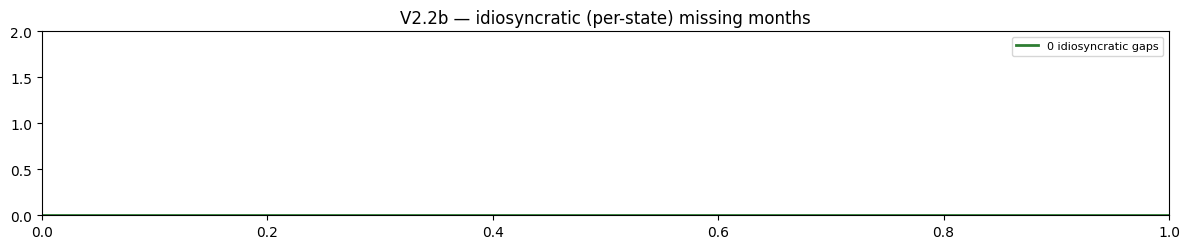

[PASS] V2.2b  Idiosyncratic (per-state) missing months  |  0 idiosyncratic month(s)  (criterion: == 0)


In [17]:
# V2.2b — idiosyncratic gaps (a single state failing to report a month)
print("V2.2b — idiosyncratic missing months (criterion: == 0; each must be investigated):")
print(f"  idiosyncratic months: {len(idiosyncratic)}")
if idiosyncratic:
    _rows = []
    for state, g in ur_c.groupby("state"):
        cal = pd.date_range(g["obs_date"].min(), g["obs_date"].max(), freq="MS")
        for d in cal.difference(g["obs_date"]):
            if miss_by_month[d] < 45:
                _rows.append({"state": state, "missing_month": d.date()})
    print(pd.DataFrame(_rows).sort_values(["missing_month", "state"]).to_string(index=False))
else:
    print("  (none — no per-state holes)")

fig, ax = plt.subplots(figsize=(12, 2.6))
ax.axhline(0, color="#2e7d32", lw=2, label="0 idiosyncratic gaps") if not idiosyncratic else None
ax.set_ylim(0, 2); ax.set_title("V2.2b — idiosyncratic (per-state) missing months"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V2", "V2.2b", "Idiosyncratic (per-state) missing months",
          "PASS" if not idiosyncratic else "WARN",
          metric=f"{len(idiosyncratic)} idiosyncratic month(s)", threshold="== 0")

## V2.3 — Panel window alignment across states

V2.3 — panel edges across states, revised (current) UR
  (criterion: start spread == 0, end spread <= 1 month)
  start spread: 0m  (1976-01-01 .. 1976-01-01)
  end spread:   0m  (2026-05-01 .. 2026-05-01)
  common balanced window: 1976-01-01 -> 2026-05-01

V2.3 — first/last obs_date per state:
                     first_month last_month  n_months
state                                                
Alabama               1976-01-01 2026-05-01       604
Nebraska              1976-01-01 2026-05-01       604
Nevada                1976-01-01 2026-05-01       604
New Hampshire         1976-01-01 2026-05-01       604
New Jersey            1976-01-01 2026-05-01       604
New Mexico            1976-01-01 2026-05-01       604
New York              1976-01-01 2026-05-01       604
North Carolina        1976-01-01 2026-05-01       604
North Dakota          1976-01-01 2026-05-01       604
Ohio                  1976-01-01 2026-05-01       604
Oklahoma              1976-01-01 2026-05-01       604
Mon

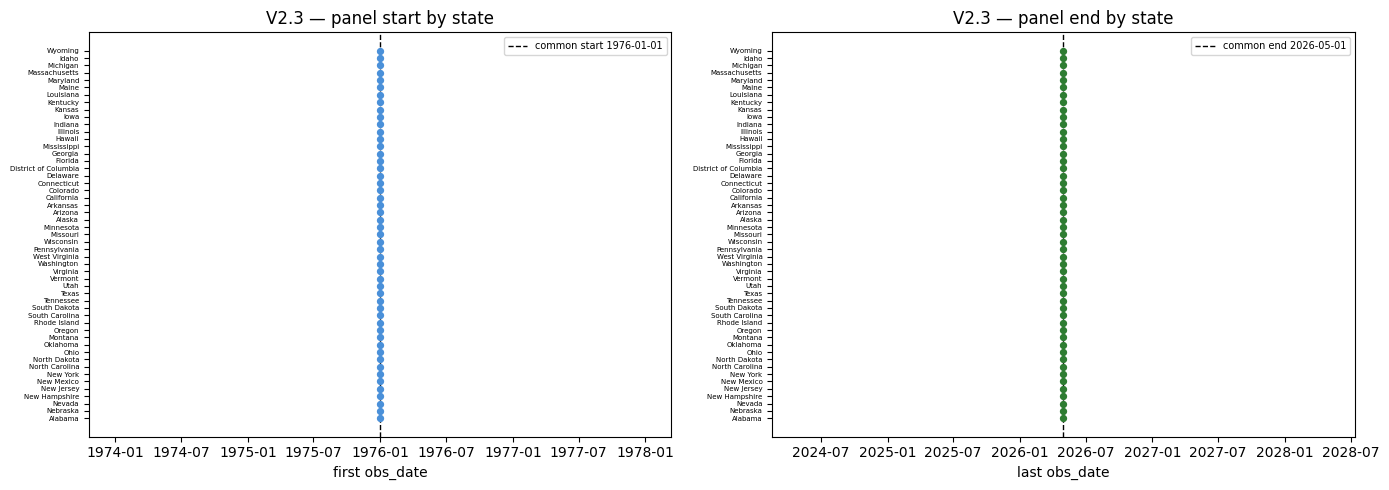

[PASS] V2.3   Panel edges aligned across states  |  start spread=0m, end spread=0m  (criterion: start==0, end<=1m)
       note: common window: 1976-01-01 -> 2026-05-01


In [18]:
# V2.3 — do all states cover the same window? (panel start/end spread)
_edges = (ur_c.groupby("state")["obs_date"].agg(first_month="min", last_month="max", n_months="count").sort_values("first_month"))
start_spread = int((_edges["first_month"].max() - _edges["first_month"].min()).days // 30)
end_spread = int((_edges["last_month"].max() - _edges["last_month"].min()).days // 30)
common_start, common_end = _edges["first_month"].max(), _edges["last_month"].min()

print("V2.3 — panel edges across states, revised (current) UR")
print(f"  (criterion: start spread == 0, end spread <= 1 month)")
print(f"  start spread: {start_spread}m  ({_edges['first_month'].min().date()} .. {_edges['first_month'].max().date()})")
print(f"  end spread:   {end_spread}m  ({_edges['last_month'].min().date()} .. {_edges['last_month'].max().date()})")
print(f"  common balanced window: {common_start.date()} -> {common_end.date()}")
print("\nV2.3 — first/last obs_date per state:")
print(_edges.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
states = _edges.index.tolist(); y = range(len(states))
axes[0].scatter(_edges["first_month"], y, c="#4a90d9", s=18, zorder=3)
axes[0].axvline(common_start, color="black", ls="--", lw=1, label=f"common start {common_start.date()}")
axes[0].set_yticks(y); axes[0].set_yticklabels(states, fontsize=5)
axes[0].set_xlabel("first obs_date"); axes[0].set_title("V2.3 — panel start by state"); axes[0].legend(fontsize=7)
axes[1].scatter(_edges["last_month"], y, c="#2e7d32", s=18, zorder=3)
axes[1].axvline(common_end, color="black", ls="--", lw=1, label=f"common end {common_end.date()}")
axes[1].set_yticks(y); axes[1].set_yticklabels(states, fontsize=5)
axes[1].set_xlabel("last obs_date"); axes[1].set_title("V2.3 — panel end by state"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

add_check("V2", "V2.3", "Panel edges aligned across states",
          "PASS" if start_spread == 0 and end_spread <= 1 else "WARN",
          metric=f"start spread={start_spread}m, end spread={end_spread}m",
          threshold="start==0, end<=1m", note=f"common window: {common_start.date()} -> {common_end.date()}")

## V3 — Point-in-time & release calendar — *information time: when the number became known*

The **information clock**. State U3 is published in the monthly *State Employment and Unemployment* report — the same release as state payrolls — ~50 days after the reference month, on a Friday, ~3 weeks after the national jobs report.

| Check | Question it answers |
|---|---|
| V3.1 | How far back can point-in-time be reconstructed? |
| V3.2 | Does the national vintage calendar match the jobs-report (Friday) schedule? |
| V3.3 | Is the state publication lag ~50 days? |
| V3.4 | Do state releases follow the national jobs report? |
| V3.5 | Is the publication-lag regime stable over time? |
| V3.6 | Do months become available in order (monotone frontier)? |
| V3.7 | Does the PIT panel contain any look-ahead? |

## V3.1 — How far back can point-in-time be reconstructed?

V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):
  first ALFRED vintage:  2005-07-22
  obs_date span:         2005-06-01 -> 2026-05-01
  PIT as_of span:        2006-08-01 -> 2026-06-01

V3.1 — first vintage date per state:
               state first_vintage
            Missouri    2005-07-22
         Mississippi    2005-07-22
            Kentucky    2005-07-22
             Indiana    2005-07-22
           Tennessee    2005-07-22
            Illinois    2005-07-22
            Arkansas    2005-07-22
                Utah    2007-07-20
       West Virginia    2007-07-20
          New Jersey    2007-07-20
          New Mexico    2007-07-20
            New York    2007-07-20
      North Carolina    2007-07-20
        North Dakota    2007-07-20
                Ohio    2007-07-20
          Washington    2007-07-20
            Oklahoma    2007-07-20
              Oregon    2007-07-20
       New Hampshire    2007-07-20
        Pennsylvania    2007-07-20
        Rhod

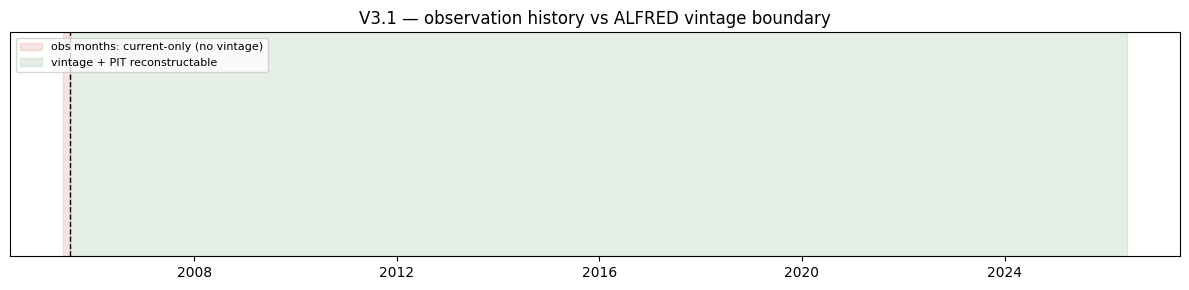

[WARN] V3.1   ALFRED vintage boundary identified  |  first vintage 2005-07-22  (criterion: documented)
       note: pre-boundary history exists only as current values: usable for climatology, NOT backtesting


In [19]:
# V3.1 — ALFRED vintage boundary
vint_start, vint_end = df_v["first_release_date"].min(), df_v["first_release_date"].max()
obs_min, obs_max = df_v["obs_date"].min(), df_v["obs_date"].max()
pit_start, pit_end = pit["as_of_date"].min(), pit["as_of_date"].max()
state_first_vint = df_v.groupby("state")["first_release_date"].min().sort_values()

print("V3.1 — point-in-time reconstruction boundary (criterion: boundary documented):")
print(f"  first ALFRED vintage:  {vint_start.date()}")
print(f"  obs_date span:         {obs_min.date()} -> {obs_max.date()}")
print(f"  PIT as_of span:        {pit_start.date()} -> {pit_end.date()}")
print("\nV3.1 — first vintage date per state:")
print(state_first_vint.reset_index(name="first_vintage").to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 3.0))
ax.axvspan(obs_min, vint_start, alpha=0.15, color="#d94a4a", label="obs months: current-only (no vintage)")
ax.axvspan(vint_start, pit_end, alpha=0.12, color="#2e7d32", label="vintage + PIT reconstructable")
ax.axvline(vint_start, color="black", ls="--", lw=1)
ax.set_yticks([]); ax.set_title("V3.1 — observation history vs ALFRED vintage boundary")
ax.legend(fontsize=8, loc="upper left"); plt.tight_layout(); plt.show()

add_check("V3", "V3.1", "ALFRED vintage boundary identified", "WARN",
          metric=f"first vintage {vint_start.date()}", threshold="documented",
          note="pre-boundary history exists only as current values: usable for climatology, NOT backtesting")

## V3.2 — Does the national vintage calendar match the jobs-report (Friday) schedule?

V3.2 — national UNRATE vintage calendar (criterion: Friday >= 80%):
    Mon    15  (1.9%)
    Tue    23  (2.9%)
    Wed    33  (4.1%)
    Thu    55  (6.9%)
    Fri   671  (84.2%)


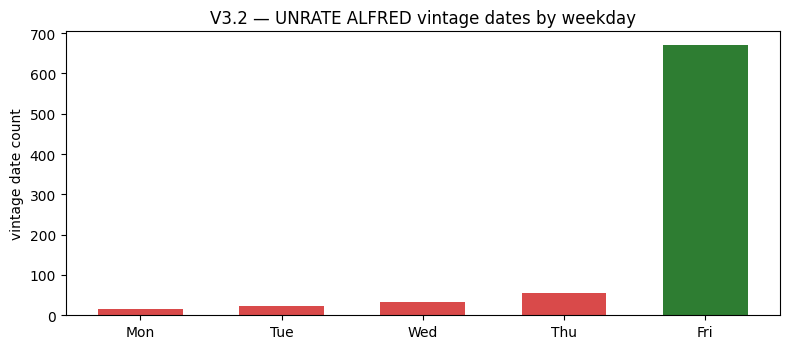

[PASS] V3.2   National UNRATE vintages land on the jobs-report day (Friday)  |  Mon 2%, Tue 3%, Wed 4%, Thu 7%, Fri 84%  (criterion: Friday >= 80%)
       note: national Employment Situation is released the first Friday after the reference month


In [20]:
# V3.2 — national UNRATE vintage dates land on the jobs-report day (Friday)
_WD = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
nat_wd = nat_vdates.dt.dayofweek.value_counts().sort_index()
fri_share = nat_wd.get(4, 0) / len(nat_vdates)

print("V3.2 — national UNRATE vintage calendar (criterion: Friday >= 80%):")
for d, n in nat_wd.items():
    print(f"    {_WD[d]:3s}  {int(n):4d}  ({n/len(nat_vdates):.1%})")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([_WD[d] for d in nat_wd.index], nat_wd.values, color=["#2e7d32" if d == 4 else "#d94a4a" for d in nat_wd.index], width=0.6)
ax.set_ylabel("vintage date count"); ax.set_title("V3.2 — UNRATE ALFRED vintage dates by weekday")
plt.tight_layout(); plt.show()

add_check("V3", "V3.2", "National UNRATE vintages land on the jobs-report day (Friday)",
          "PASS" if fri_share >= 0.80 else "WARN",
          metric=", ".join(f"{_WD[k]} {nat_wd.get(k,0)/len(nat_vdates):.0%}" for k in nat_wd.index if nat_wd.get(k,0)/len(nat_vdates) >= 0.01),
          threshold="Friday >= 80%", note="national Employment Situation is released the first Friday after the reference month")

## V3.3 — Is the state publication lag ~50 days?

V3.3 — state UR publication lag (criterion: median in [40, 60] days):
                count  mean  std   min   25%   50%   75%    max
pub_lag_days  11745.0  52.3  8.5  45.0  48.0  50.0  53.0  111.0
  median=50d  (~1.7 months; released with state payrolls, ~3 weeks after the national report)


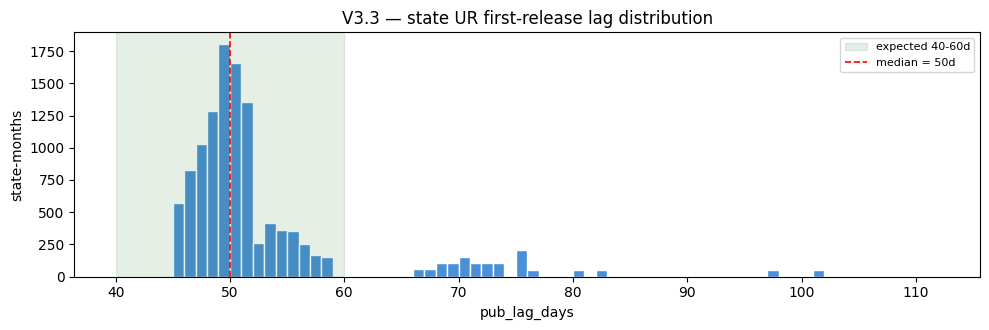

[PASS] V3.3   State publication lag ~50 days (joint state emp/unemp report)  |  median 50d (IQR 48-53)  (criterion: median in [40, 60] days)
       note: released together with state payrolls, ~3 weeks after national


In [21]:
# V3.3 — state publication lag (obs month-start to first release)
_lag = df_v["pub_lag_days"]
med = float(_lag.median())
print("V3.3 — state UR publication lag (criterion: median in [40, 60] days):")
print(_lag.describe().round(1).to_frame("pub_lag_days").T.to_string())
print(f"  median={med:.0f}d  (~{med/30:.1f} months; released with state payrolls, ~3 weeks after the national report)")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(_lag, bins=range(int(_lag.min()), int(_lag.max()) + 2), color="#4a90d9", edgecolor="white")
ax.axvspan(40, 60, color="#2e7d32", alpha=0.12, label="expected 40-60d")
ax.axvline(med, color="red", ls="--", lw=1.2, label=f"median = {med:.0f}d")
ax.set_xlabel("pub_lag_days"); ax.set_ylabel("state-months"); ax.set_title("V3.3 — state UR first-release lag distribution")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

add_check("V3", "V3.3", "State publication lag ~50 days (joint state emp/unemp report)",
          "PASS" if 40 <= med <= 60 else "WARN",
          metric=f"median {med:.0f}d (IQR {_lag.quantile(.25):.0f}-{_lag.quantile(.75):.0f})",
          threshold="median in [40, 60] days", note="released together with state payrolls, ~3 weeks after national")

## V3.4 — Do state releases follow the national jobs report?

V3.4 — state release vs national jobs report (criterion: >= 95% after national):
  share released after national: 100.0%  median gap +14d
            count  mean  std   min   25%   50%   75%   max
gap_days  11745.0  17.7  7.3  14.0  14.0  14.0  18.0  70.0


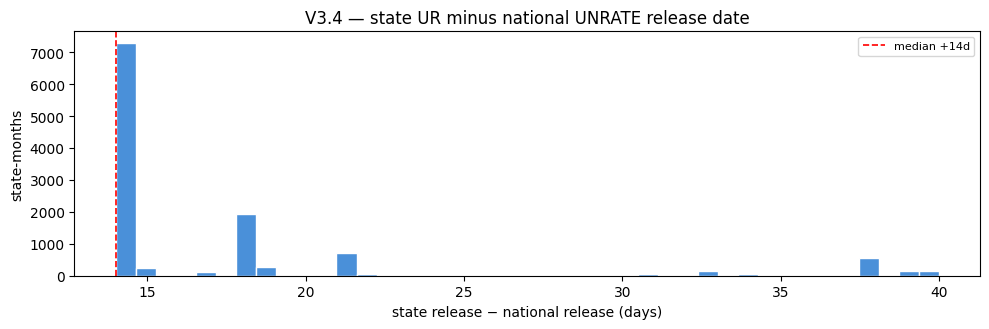

[PASS] V3.4   State UR published after the national jobs report  |  100.0% after national; median gap +14d  (criterion: >= 95% after national)
       note: state detail follows the national aggregate


In [22]:
# V3.4 — state first release lands after the national UNRATE release for the same month
nat_rel = nat_v.set_index("obs_date")["first_release_date"]
al = df_v[["state", "obs_date", "first_release_date", "pub_lag_days"]].copy()
al["nat_release"] = al["obs_date"].map(nat_rel)
al = al.dropna(subset=["nat_release"])
al["gap_days"] = (al["first_release_date"] - al["nat_release"]).dt.days
after = (al["gap_days"] > 0).mean()

print("V3.4 — state release vs national jobs report (criterion: >= 95% after national):")
print(f"  share released after national: {after:.1%}  median gap +{al['gap_days'].median():.0f}d")
print(al["gap_days"].describe().round(1).to_frame("gap_days").T.to_string())

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(al["gap_days"].clip(0, 40), bins=41, color="#4a90d9", edgecolor="white")
ax.axvline(al["gap_days"].median(), color="red", ls="--", lw=1.2, label=f"median +{al['gap_days'].median():.0f}d")
ax.set_xlabel("state release − national release (days)"); ax.set_ylabel("state-months")
ax.set_title("V3.4 — state UR minus national UNRATE release date"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

add_check("V3", "V3.4", "State UR published after the national jobs report",
          "PASS" if after >= 0.95 else "WARN",
          metric=f"{after:.1%} after national; median gap +{al['gap_days'].median():.0f}d",
          threshold=">= 95% after national", note="state detail follows the national aggregate")

## V3.5 — Is the publication-lag regime stable over time?

V3.5 — publication-lag regime stability (criterion: yearly median range <= 7 days):
  median lag by year spans 48-66d (range 18d)
rel_year    2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
median_lag  49.5  50.5  50.0  48.5  50.0  50.5  49.5  50.0  49.5  49.5  50.5  49.5  49.5  49.5  49.0  49.5  50.0  49.0  49.5  49.5  52.0  66.0


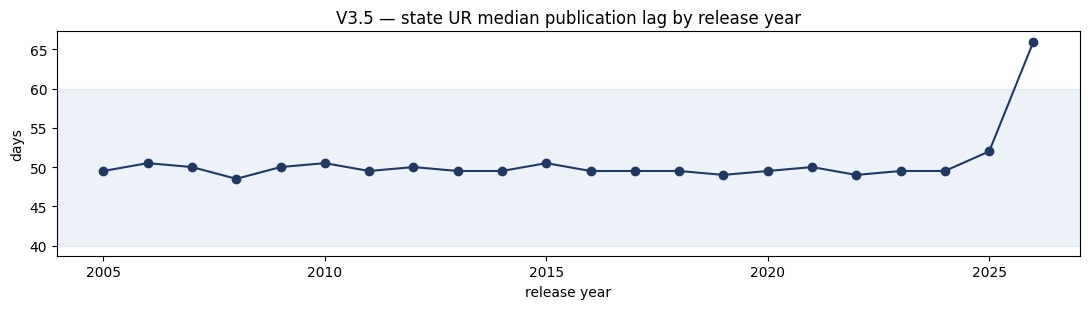

[WARN] V3.5   Publication-lag regime stable over time  |  yearly median range 18d (48-66d)  (criterion: yearly median range <= 7 days)
       note: a stable lag lets a backtest assume a single availability rule


In [23]:
# V3.5 — lag stability by release year
df_v["rel_year"] = df_v["first_release_date"].dt.year
lag_by_year = df_v.groupby("rel_year")["pub_lag_days"].median()
lag_range = lag_by_year.max() - lag_by_year.min()

print("V3.5 — publication-lag regime stability (criterion: yearly median range <= 7 days):")
print(f"  median lag by year spans {lag_by_year.min():.0f}-{lag_by_year.max():.0f}d (range {lag_range:.0f}d)")
print(lag_by_year.round(1).to_frame("median_lag").T.to_string())

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(lag_by_year.index, lag_by_year.values, marker="o", color="#1f3864")
ax.axhspan(40, 60, color="steelblue", alpha=0.10)
ax.set(title="V3.5 — state UR median publication lag by release year", ylabel="days", xlabel="release year")
plt.tight_layout(); plt.show()

add_check("V3", "V3.5", "Publication-lag regime stable over time",
          "PASS" if lag_range <= 7 else "WARN",
          metric=f"yearly median range {lag_range:.0f}d ({lag_by_year.min():.0f}-{lag_by_year.max():.0f}d)",
          threshold="yearly median range <= 7 days", note="a stable lag lets a backtest assume a single availability rule")

## V3.6 — Do months become available in order (monotone frontier)?

V3.6 — availability-frontier monotonicity (criterion: 0 inversions):
  total inversions: 0
  (all states monotone)


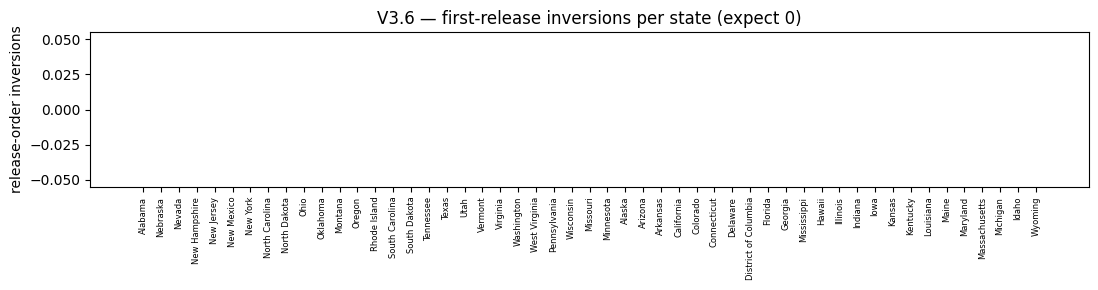

[PASS] V3.6   Release dates weakly increasing in obs order (per state)  |  0 inversions  (criterion: == 0)
       note: the PIT builder uses the cummax release frontier, so small inversions are harmless


In [24]:
# V3.6 — release dates weakly increasing in observation order, per state
inversions = 0
per_state_inv = {}
for state, g in df_v.groupby("state"):
    rel = g.sort_values("obs_date")["first_release_date"].values
    n = int((rel[1:] < rel[:-1]).sum()); per_state_inv[state] = n; inversions += n

print("V3.6 — availability-frontier monotonicity (criterion: 0 inversions):")
print(f"  total inversions: {inversions}")
_bad = {s: n for s, n in per_state_inv.items() if n}
print("  (all states monotone)" if not _bad else f"  states with inversions: {_bad}")

fig, ax = plt.subplots(figsize=(11, 3.0))
vals = pd.Series(per_state_inv).sort_values()
ax.bar(range(len(vals)), vals.values, color=["#2e7d32" if v == 0 else "#d94a4a" for v in vals.values], width=0.85)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, rotation=90, fontsize=6)
ax.set_ylabel("release-order inversions"); ax.set_title("V3.6 — first-release inversions per state (expect 0)")
plt.tight_layout(); plt.show()

add_check("V3", "V3.6", "Release dates weakly increasing in obs order (per state)",
          "PASS" if inversions == 0 else "WARN", metric=f"{inversions} inversions", threshold="== 0",
          note="the PIT builder uses the cummax release frontier, so small inversions are harmless")

## V3.7 — Does the PIT panel contain any look-ahead?

V3.7 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):
  violations (released AFTER as_of): 0
  unmatched latest-obs keys:         0
  data-staleness (ur_lag_months): median=2  min=2  max=4


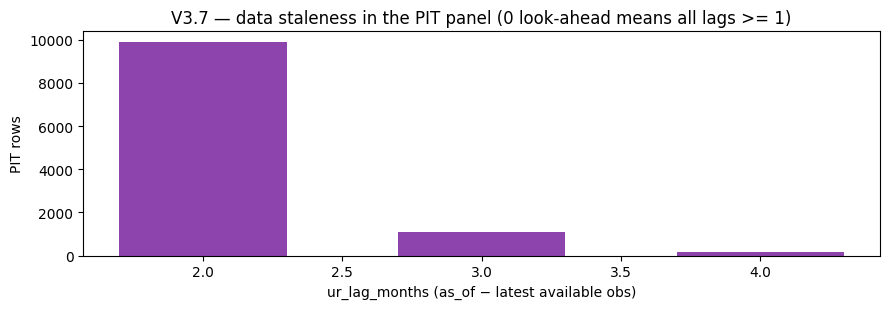

[PASS] V3.7   PIT panel look-ahead guard (ur_latest_obs released <= as_of_date)  |  0 violations, 0 unmatched of 11,133 rows  (criterion: == 0)


In [25]:
# V3.7 — hard look-ahead guard: each PIT row's latest obs was released on/before its as_of_date
rel_lookup = df_v.set_index(["state", "obs_date"])["first_release_date"]
keys = pd.MultiIndex.from_arrays([pit["state"], pit["ur_latest_obs"]])
pit_rel = rel_lookup.reindex(keys).values
violations = int((pd.to_datetime(pit_rel) > pit["as_of_date"]).sum())
unmatched = int(pd.isna(pit_rel).sum())
_lag_months = pit["ur_lag_months"]

print("V3.7 — PIT look-ahead guard (criterion: 0 violations, 0 unmatched):")
print(f"  violations (released AFTER as_of): {violations}")
print(f"  unmatched latest-obs keys:         {unmatched}")
print(f"  data-staleness (ur_lag_months): median={_lag_months.median():.0f}  min={_lag_months.min()}  max={_lag_months.max()}")

fig, ax = plt.subplots(figsize=(9, 3.2))
vc = _lag_months.value_counts().sort_index()
ax.bar(vc.index, vc.values, color="#8e44ad", width=0.6)
ax.set_xlabel("ur_lag_months (as_of − latest available obs)"); ax.set_ylabel("PIT rows")
ax.set_title("V3.7 — data staleness in the PIT panel (0 look-ahead means all lags >= 1)")
plt.tight_layout(); plt.show()

add_check("V3", "V3.7", "PIT panel look-ahead guard (ur_latest_obs released <= as_of_date)",
          "PASS" if violations == 0 and unmatched == 0 else "FAIL",
          metric=f"{violations} violations, {unmatched} unmatched of {len(pit):,} rows", threshold="== 0")

## V4 — Revision behavior: first release and after

U3 sits between claims (never revised) and payrolls (always revised): most revisions are small and, because the rate is published to 0.1pp, many round to exactly zero. The annual LAUS benchmark still drives the larger ones.

| Check | Question it answers |
|---|---|
| V4.1 | How often, and by how much, does a first print get revised (endpoint: first vs current)? |
| V4.2 | Do the larger revisions cluster at the annual (winter) benchmark? |
| V4.3 | Is there a systematic bias in first prints? |
| V4.4 | How large is the national UNRATE revision (calibration)? |

Revisions are measured in **percentage points** (the rate is bounded, so pp changes are the natural unit).

## V4.1 — How often does a first print get revised (endpoint: first vs current)?

V4.1 — endpoint revision rate & magnitude (criterion: informational; quantized to 0.1pp):
  rows compared: 11,745
  revised (|rev| > 0):  86%
  exact-zero:           14%
  within +-0.1pp:       25%
  within +-0.5pp:       84%
  max |revision|:       4.1pp


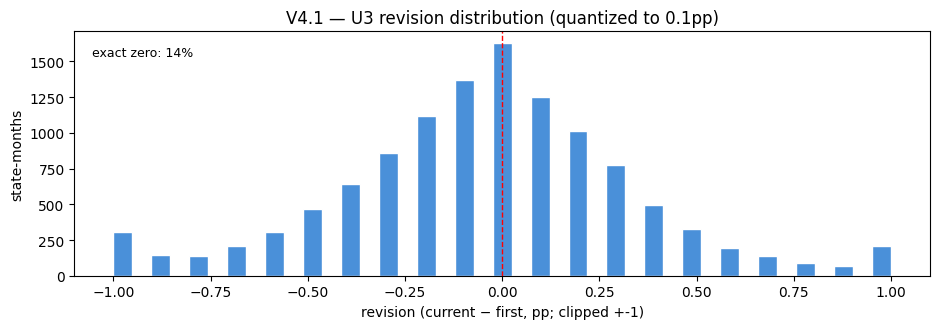


V4.1 — largest revisions (current − first, pp):
         state obs_date first_release_date  value_first_release  value_current  revision
       Wyoming  2020-04         2020-05-22                  9.2            5.1      -4.1
        Nevada  2020-06         2020-07-17                 15.0           18.9       3.9
      Michigan  2020-07         2020-08-21                  8.7           12.5       3.8
    New Mexico  2020-07         2020-08-21                 12.7            9.0      -3.7
 Massachusetts  2020-07         2020-08-21                 16.1           12.5      -3.6
         Maine  2020-07         2020-08-21                  9.9            6.3      -3.6
        Hawaii  2020-06         2020-07-17                 13.9           17.3       3.4
      New York  2020-07         2020-08-21                 15.9           12.6      -3.3
  Pennsylvania  2020-07         2020-08-21                 13.7           10.4      -3.3
South Carolina  2020-05         2020-06-19                 12

In [26]:
# V4.1 — endpoint revision: first release vs current (percentage points)
rev = df_v.merge(ur_c[["state", "obs_date", "value_current"]], on=["state", "obs_date"], how="inner")
rev["revision"] = rev["value_current"] - rev["value_first_release"]
exceptions = rev[rev["revision"].abs() > 1e-9].copy()
share_rev = len(exceptions) / len(rev)

print("V4.1 — endpoint revision rate & magnitude (criterion: informational; quantized to 0.1pp):")
print(f"  rows compared: {len(rev):,}")
print(f"  revised (|rev| > 0):  {share_rev:.0%}")
print(f"  exact-zero:           {(rev['revision'] == 0).mean():.0%}")
print(f"  within +-0.1pp:       {(rev['revision'].abs() <= 0.1).mean():.0%}")
print(f"  within +-0.5pp:       {(rev['revision'].abs() <= 0.5).mean():.0%}")
print(f"  max |revision|:       {rev['revision'].abs().max():.1f}pp")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.hist(rev["revision"].clip(-1, 1), bins=41, color="#4a90d9", edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set_xlabel("revision (current − first, pp; clipped +-1)"); ax.set_ylabel("state-months")
ax.set_title("V4.1 — U3 revision distribution (quantized to 0.1pp)")
ax.text(0.02, 0.9, f"exact zero: {(rev['revision'] == 0).mean():.0%}", transform=ax.transAxes, fontsize=9)
plt.tight_layout(); plt.show()

print("\nV4.1 — largest revisions (current − first, pp):")
cols = ["state", "obs_date", "first_release_date", "value_first_release", "value_current", "revision"]
_top = rev.reindex(rev["revision"].abs().sort_values(ascending=False).index).head(10)[cols].copy()
_top["obs_date"] = _top["obs_date"].dt.strftime("%Y-%m")
_top["first_release_date"] = _top["first_release_date"].dt.strftime("%Y-%m-%d")
print(_top.to_string(index=False))
rev.to_csv("ur_revisions.csv", index=False)

add_check("V4", "V4.1", "Endpoint revision rate & magnitude (first release vs current, pp)",
          "WARN" if share_rev > 0.05 else "PASS",
          metric=f"{share_rev:.0%} revised; exact-zero {(rev['revision']==0).mean():.0%}, within +-0.5pp {(rev['revision'].abs()<=0.5).mean():.0%}, max |{rev['revision'].abs().max():.1f}|pp",
          threshold="informational — moderately, quantized-revised",
          note="between claims (~0%) and NFP (~99%); benchmark years and COVID exceed 1pp — backtests still need vintage data")

## V4.2 — Do the larger revisions cluster at the annual (winter) benchmark?

V4.2 — release month of each obs-month's LARGEST revision (criterion: >= 50% in Jan-Apr):
  Jan-Apr share: 99%   modal month: 3  (1581 of 1656 obs, CA/TX/NY)


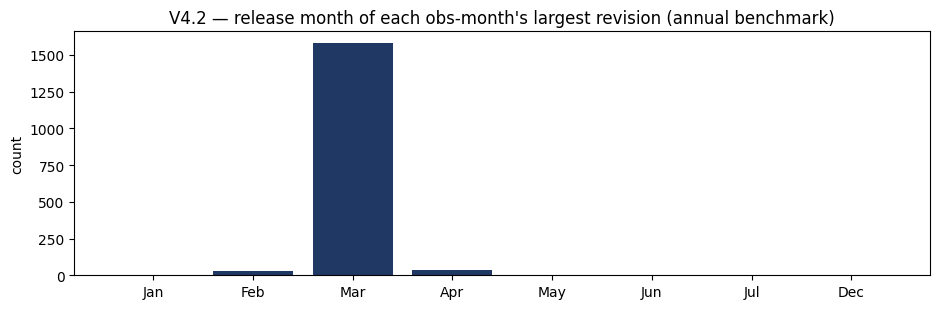

[PASS] V4.2   Larger revisions cluster at the annual benchmark (winter release months)  |  99% of largest revisions in Jan-Apr; modal month = 3  (criterion: >= 50% in the winter benchmark window)
       note: annual LAUS re-estimation/re-seasonal-adjustment lands each winter; apply on release date, not backward


In [27]:
# V4.2 — full vintage trajectories (output_type=2) for sample states: when do biggest revisions land?
BENCH = {"CAUR": "California", "TXUR": "Texas", "NYUR": "New York"}
bench_months = []
for sid, name in BENCH.items():
    d = fred_get({"series_id": sid, "realtime_start": "1776-07-04", "realtime_end": "9999-12-31",
                  "output_type": 2, "limit": 100000})
    t = pd.DataFrame(d["observations"]).set_index("date")
    vcols = [c for c in t.columns if c.startswith(sid)]
    vals = t[vcols].replace(".", np.nan).astype(float)
    vals.columns = pd.to_datetime([c.split("_", 1)[1] for c in vcols])
    for obs in vals.index:
        row = vals.loc[obs].dropna()
        if len(row) < 2:
            continue
        steps = row.diff().abs()
        if steps.max() > 0:
            bench_months.append(steps.idxmax().month)
    time.sleep(0.3)
bm = pd.Series(bench_months).value_counts().sort_index()
winter = bm.reindex([1, 2, 3, 4]).sum() / bm.sum()

print("V4.2 — release month of each obs-month's LARGEST revision (criterion: >= 50% in Jan-Apr):")
print(f"  Jan-Apr share: {winter:.0%}   modal month: {bm.idxmax()}  ({bm.max()} of {bm.sum()} obs, CA/TX/NY)")

_mn = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
ax.bar([_mn[m-1] for m in bm.index], bm.values, color=["#1f3864" if m in (1,2,3,4) else "#8ab4e0" for m in bm.index])
ax.set(title="V4.2 — release month of each obs-month's largest revision (annual benchmark)", ylabel="count")
plt.tight_layout(); plt.show()

add_check("V4", "V4.2", "Larger revisions cluster at the annual benchmark (winter release months)",
          "PASS" if winter >= 0.5 else "WARN",
          metric=f"{winter:.0%} of largest revisions in Jan-Apr; modal month = {bm.idxmax()}",
          threshold=">= 50% in the winter benchmark window",
          note="annual LAUS re-estimation/re-seasonal-adjustment lands each winter; apply on release date, not backward")

## V4.3 — Is there a systematic bias in first prints?

V4.3 — systematic bias in first prints (criterion: |mean revision| < 0.03pp):
  mean revision: -0.047pp  (first prints overstate on average)
  median: +0.00pp   std: 0.45pp


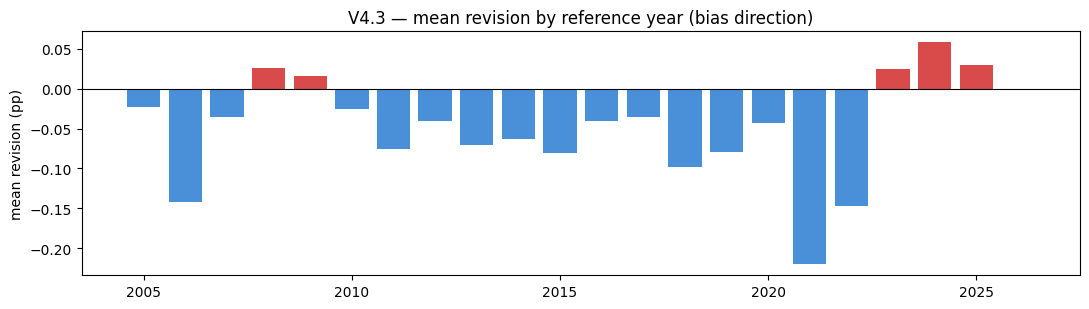

[WARN] V4.3   Systematic bias in first prints  |  mean revision -0.047pp  (criterion: |mean| < 0.03pp)
       note: a small persistent sign is expected from benchmark direction


In [28]:
# V4.3 — directional bias of first prints
bias = rev["revision"].mean()
print("V4.3 — systematic bias in first prints (criterion: |mean revision| < 0.03pp):")
print(f"  mean revision: {bias:+.3f}pp  (first prints {'understate' if bias > 0 else 'overstate'} on average)")
print(f"  median: {rev['revision'].median():+.2f}pp   std: {rev['revision'].std():.2f}pp")

_by_year = rev.assign(y=rev["obs_date"].dt.year).groupby("y")["revision"].mean()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(_by_year.index, _by_year.values, color=["#d94a4a" if v > 0 else "#4a90d9" for v in _by_year.values])
ax.axhline(0, color="black", lw=0.8)
ax.set(title="V4.3 — mean revision by reference year (bias direction)", ylabel="mean revision (pp)")
plt.tight_layout(); plt.show()

add_check("V4", "V4.3", "Systematic bias in first prints",
          "PASS" if abs(bias) < 0.03 else "WARN",
          metric=f"mean revision {bias:+.3f}pp", threshold="|mean| < 0.03pp",
          note="a small persistent sign is expected from benchmark direction")

## V4.4 — How large is the national UNRATE revision (calibration)?

V4.4 — national UNRATE revision (criterion: informational calibration):
  median +0.00pp  IQR [+0.00, +0.10]  max |0.4|pp


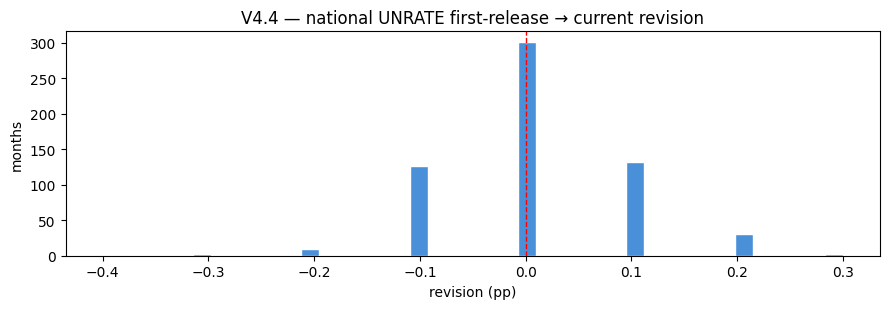

[PASS] V4.4   National UNRATE revision benchmark quantified  |  median +0.00pp, max |0.4|pp  (criterion: informational calibration)
       note: the national rate is revised on the same schedule; anchors state expectations


In [29]:
# V4.4 — national UNRATE revision benchmark (first release vs current)
nat_rev = nat_v.merge(nat_cur[["obs_date", "value"]].rename(columns={"value": "current"}), on="obs_date", how="inner")
nat_rev["rev"] = nat_rev["current"] - nat_rev["value"]

print("V4.4 — national UNRATE revision (criterion: informational calibration):")
print(f"  median {nat_rev['rev'].median():+.2f}pp  IQR [{nat_rev['rev'].quantile(.25):+.2f}, {nat_rev['rev'].quantile(.75):+.2f}]  max |{nat_rev['rev'].abs().max():.1f}|pp")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(nat_rev["rev"].clip(-0.5, 0.5), bins=41, color="#4a90d9", edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.set(title="V4.4 — national UNRATE first-release → current revision", xlabel="revision (pp)", ylabel="months")
plt.tight_layout(); plt.show()

add_check("V4", "V4.4", "National UNRATE revision benchmark quantified", "PASS",
          metric=f"median {nat_rev['rev'].median():+.2f}pp, max |{nat_rev['rev'].abs().max():.1f}|pp",
          threshold="informational calibration", note="the national rate is revised on the same schedule; anchors state expectations")